# Trabalho A2 — Data Science

**Alunos:** Arthur Ribeiro, Marcos Vitor, Gabriel Asserman e Eduardo Bernardes

## Análise de probabilidade em classificação binária

Objetivo: desenvolver um programa que produza um gráfico baseado em histogramas para
analisar a distribuição das probabilidades previstas por um modelo de classificação
binária e apoiar a definição de faixas de decisão.

Modelos de classificação binária normalmente não retornam apenas "0" ou "1" —
eles retornam a probabilidade estimada de uma instância pertencer à classe
positiva. Cabe a quem usa o modelo decidir, a partir dessa probabilidade,
onde ficam os pontos de corte que separam decisões automáticas de casos que
precisam de revisão manual.

**O que esta parte do notebook oferece:**

- `plot_histogram`: gera um histograma comparando a distribuição de
  probabilidades de toda a população com a distribuição apenas da classe
  positiva, já destacando visualmente as três faixas de decisão (negativo
  automático, análise manual, positivo automático).
- `assign_decision_band`: classifica cada instância em uma dessas três
  faixas, a partir de dois cortes `t1 < t2`.
- `decision_band_report`: gera o relatório numérico de cada faixa (percentual
  da população, proporção de positivos/negativos, e as proporções de erro de
  classificação automática, com o denominador de cada uma explícito).

**Reutilização:** as funções trabalham apenas com os rótulos reais (`y_true`)
e as probabilidades estimadas (`y_prob`) — não dependem de nenhum dataset ou
modelo específico. Os cortes `t1`/`t2` devem ser escolhidos observando dados
de **validação** e aplicados ao conjunto de **teste** sem novos ajustes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def assign_decision_band(y_prob, t1, t2):
    """
    Classifica cada instância em uma das 3 faixas de decisão, a partir de dois
    cortes t1 < t2 (definidos previamente com dados de VALIDAÇÃO).

    Retorna um array de strings, uma por instância:
    - "negativo_automatico": probabilidade < t1
    - "analise_manual":      t1 <= probabilidade < t2
    - "positivo_automatico": probabilidade >= t2
    """
    assert t1 < t2, "t1 precisa ser menor que t2"

    y_prob = np.asarray(y_prob)
    faixa = np.full(len(y_prob), "analise_manual", dtype=object)
    faixa[y_prob < t1] = "negativo_automatico"
    faixa[y_prob >= t2] = "positivo_automatico"
    return faixa


def plot_histogram(y_true, y_prob, t1, t2, positive_class_definition, bin_width_pct=10):
    """
    y_true: rótulos reais (0/1) das instâncias.
    y_prob: probabilidade estimada da classe positiva, para TODAS as instâncias
            (independente de y_true) — não filtrar por rótulo real antes de passar aqui.
    t1, t2: cortes (t1 < t2) que definem as 3 faixas de decisão, escolhidos
            previamente com dados de VALIDAÇÃO.
    positive_class_definition: string explicando o que "classe positiva" significa
            neste problema (ex: "é spam?", "é fraude?", "expressa sentimento positivo?").
    bin_width_pct: largura de cada intervalo do histograma, em pontos percentuais
            (ex: 10 -> intervalos de 0-10%, 10-20%, ..., 90-100%).

    Ao gerar os resultados finais do trabalho, chamar esta função apenas com
    y_true/y_prob do CONJUNTO DE TESTE — nunca com dados de treino ou validação.
    """
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    assert len(y_true) == len(y_prob), "cada instância precisa ter rótulo real e probabilidade correspondente"
    assert t1 < t2, "t1 precisa ser menor que t2"
    assert 100 % bin_width_pct == 0, "bin_width_pct precisa dividir 100 igualmente (ex: 5, 10, 20, 25)"

    y_prob_pct = y_prob * 100
    total_instancias = len(y_prob_pct)

    n_bins = 100 // bin_width_pct
    bin_edges = np.linspace(0, 100, n_bins + 1)  # bins meio-abertos: cada instância cai em exatamente um intervalo
    centros = (bin_edges[:-1] + bin_edges[1:]) / 2

    # Mesmos bin_edges para as duas distribuições, para que sejam comparáveis ponto a ponto
    contagem_total, _ = np.histogram(y_prob_pct, bins=bin_edges)
    contagem_positiva, _ = np.histogram(y_prob_pct[y_true == 1], bins=bin_edges)

    # Mesmo denominador (total_instancias) nas duas — o vermelho é um subconjunto do azul,
    # nunca deve ser normalizado pelo próprio total de positivos.
    pct_total = contagem_total / total_instancias * 100
    pct_positiva = contagem_positiva / total_instancias * 100

    t1_pct, t2_pct = t1 * 100, t2 * 100
    faixa = assign_decision_band(y_prob, t1, t2)
    pct_por_faixa = {nome: (faixa == nome).sum() / total_instancias * 100 for nome in
                      ["negativo_automatico", "analise_manual", "positivo_automatico"]}

    largura_barra = bin_width_pct * 0.4

    fig, ax = plt.subplots(figsize=(11, 5.5))

    ax.axvspan(0, t1_pct, color="gray", alpha=0.12)
    ax.axvspan(t1_pct, t2_pct, color="gold", alpha=0.15)
    ax.axvspan(t2_pct, 100, color="green", alpha=0.12)

    ax.bar(centros - largura_barra / 2, pct_total, width=largura_barra,
           color="blue", hatch="//", edgecolor="blue", fill=False, label="Todas as instâncias")
    ax.bar(centros + largura_barra / 2, pct_positiva, width=largura_barra,
           color="red", hatch="//", edgecolor="red", fill=False,
           label=f"Classe positiva ({positive_class_definition})")

    ax.axvline(t1_pct, color="black", linestyle="--", linewidth=1.5)
    ax.axvline(t2_pct, color="black", linestyle="--", linewidth=1.5)

    y_topo = max(pct_total.max(), pct_positiva.max()) * 1.3
    ax.set_ylim(0, y_topo)
    rotulos = {
        "negativo_automatico": ("Negativo automático", (0 + t1_pct) / 2),
        "analise_manual": ("Análise manual", (t1_pct + t2_pct) / 2),
        "positivo_automatico": ("Positivo automático", (t2_pct + 100) / 2),
    }
    for nome, (titulo, x_centro) in rotulos.items():
        ax.text(x_centro, y_topo * 0.97, f"{titulo}\n{pct_por_faixa[nome]:.1f}% da população",
                ha="center", va="top", fontsize=9)

    ax.set_xlabel("Probabilidade estimada da classe positiva (%)")
    ax.set_ylabel("Instâncias do conjunto avaliado (%)")
    ax.set_xlim(0, 100)
    ax.set_xticks(sorted(set(bin_edges) | {t1_pct, t2_pct}))
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
    fig.tight_layout()
    plt.show()

    return fig, ax

In [2]:
import pandas as pd


def decision_band_report(y_true, y_prob, t1, t2):
    """
    Aplica os cortes t1/t2 (já definidos com dados de VALIDAÇÃO) ao conjunto
    passado aqui (deve ser o conjunto de TESTE) e monta o relatório exigido:
    percentual da população por faixa, positivos/negativos por faixa, e as
    duas proporções de erro automatizado, cada uma com seu denominador.
    """
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    faixa = assign_decision_band(y_prob, t1, t2)

    total = len(y_prob)
    total_positivos_reais = (y_true == 1).sum()
    total_negativos_reais = (y_true == 0).sum()

    linhas = []
    for nome_faixa in ["negativo_automatico", "analise_manual", "positivo_automatico"]:
        na_faixa = faixa == nome_faixa
        n = na_faixa.sum()
        pos = ((y_true == 1) & na_faixa).sum()
        neg = ((y_true == 0) & na_faixa).sum()
        linhas.append({
            "Faixa": nome_faixa,
            "Instâncias": n,
            "% da população (n / total_teste)": round(n / total * 100, 2),
            "Positivos reais": pos,
            "% positivos na faixa (pos / n)": round(pos / n * 100, 2) if n else float("nan"),
            "Negativos reais": neg,
            "% negativos na faixa (neg / n)": round(neg / n * 100, 2) if n else float("nan"),
        })
    tabela = pd.DataFrame(linhas)

    # Denominador: total de POSITIVOS REAIS (não o tamanho da faixa, não o total geral)
    positivos_perdidos = ((y_true == 1) & (faixa == "negativo_automatico")).sum()
    prop_positivos_perdidos = positivos_perdidos / total_positivos_reais

    # Denominador: total de NEGATIVOS REAIS (não o tamanho da faixa, não o total geral)
    negativos_mal_classificados = ((y_true == 0) & (faixa == "positivo_automatico")).sum()
    prop_negativos_mal_classificados = negativos_mal_classificados / total_negativos_reais

    print("Relatório por faixa de decisão (conjunto de teste):")
    display(tabela)
    print(
        f"\nPositivos reais classificados automaticamente como negativos: "
        f"{positivos_perdidos}/{total_positivos_reais} "
        f"({prop_positivos_perdidos * 100:.2f}%; denominador = total de positivos reais)"
    )
    print(
        f"Negativos reais classificados automaticamente como positivos: "
        f"{negativos_mal_classificados}/{total_negativos_reais} "
        f"({prop_negativos_mal_classificados * 100:.2f}%; denominador = total de negativos reais)"
    )

    return tabela

# Heart Failure Prediction Dataset

**Responsável pelo caso:** Eduardo Bernardes

**Fonte:** https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction

**Owner:** fedesoriano

**Licença:** Open Database License (ODbL)

**Descrição:** base de dados clínica com 918 pacientes, combinando registros
de 5 bases distintas (Cleveland, Hungarian, Switzerland, Long Beach VA e
Statlog Heart). Cada linha representa um paciente, descrito por indicadores
clínicos como idade, sexo, tipo de dor no peito, pressão arterial em
repouso, colesterol, glicemia em jejum, resultado do eletrocardiograma em
repouso, frequência cardíaca máxima atingida, angina induzida por exercício
e depressão do segmento ST. O objetivo é prever se o paciente tem ou não
doença cardíaca.

**Variável-Alvo:** `HeartDisease` — **Classe Positiva:** 1 = "o paciente tem doença cardíaca".

In [3]:
import pandas as pd

df = pd.read_csv('./data/heart.csv', sep =',')
df.head(5)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


Identificamos nossa variável-alvo e não precisaremos fazer nenhuma mudança,
pois o valor já vem formatado em 0 e 1 (binário).

Verificação do percentual de balanceamento.

Isso é muito importante pois existe um grande gap entre bases desbalanceadas
e balanceadas. Bases balanceadas são aquelas que têm valores positivos e
negativos em proporções parecidas — isso mostra que o erro, independente do
lado, tem consequências semelhantes. Bases desbalanceadas, onde temos uma
classe rara, exigem que usemos métricas e tomemos decisões de forma
diferente (como já discutimos: acurácia sozinha enganaria nesse cenário).

In [4]:
contagem_classes = df.groupby('HeartDisease')['HeartDisease'].count()
porcentagem_classes = contagem_classes / contagem_classes.sum() * 100
print(porcentagem_classes)

HeartDisease
0    44.662309
1    55.337691
Name: HeartDisease, dtype: float64


A base está bem balanceada (44,7% classe 0 / 55,3% classe 1) — bem diferente
do desbalanceamento extremo visto no spam do professor (86,6%/13,4%). Isso
significa que a acurácia deixa de ser uma métrica enganosa aqui, já que não
existe uma classe "rara" escondendo o desempenho real do modelo.

Porém, balanceamento de classes e custo do erro são coisas diferentes. Mesmo
com a base balanceada, os dois tipos de erro **não têm o mesmo custo** neste
domínio:

- **Falso negativo** (dizer que o paciente não tem doença cardíaca quando na
  verdade tem) é o erro mais grave: o paciente sai sem tratamento, achando
  que está saudável, e o problema pode se agravar sem que ninguém perceba.
- **Falso positivo** (dizer que o paciente tem doença cardíaca quando não
  tem) é um erro mais barato: na pior das hipóteses, o paciente faz alguns
  exames extras para confirmar que está tudo bem.

Por isso, mesmo com a base balanceada, vamos priorizar minimizar falsos
negativos ao escolher os cortes `t1`/`t2` — preferindo encaminhar mais casos
para análise manual (faixa intermediária) a arriscar automatizar uma
classificação negativa que pode estar errada.

### 1. Qualidade dos dados

Antes de treinar, conferimos se os valores fazem sentido clinicamente.
Duas colunas têm valores **zero**, que são fisiologicamente impossíveis
para um paciente vivo:

- `Cholesterol = 0` (colesterol sérico em mg/dl)
- `RestingBP = 0` (pressão arterial em repouso em mm Hg)

In [5]:
zeros_colesterol = df['Cholesterol'] == 0
zeros_pressao = df['RestingBP'] == 0

print(f"Cholesterol = 0: {zeros_colesterol.sum()} pacientes "
      f"({zeros_colesterol.mean() * 100:.1f}% da base)")
print(f"RestingBP   = 0: {zeros_pressao.sum()} paciente(s)")

# Taxa de doença cardíaca entre quem tem colesterol zerado x quem tem valor real
print(f"\n% com doença cardíaca quando Cholesterol = 0: "
      f"{df.loc[zeros_colesterol, 'HeartDisease'].mean() * 100:.1f}%")
print(f"% com doença cardíaca quando Cholesterol > 0: "
      f"{df.loc[~zeros_colesterol, 'HeartDisease'].mean() * 100:.1f}%")

Cholesterol = 0: 172 pacientes (18.7% da base)
RestingBP   = 0: 1 paciente(s)

% com doença cardíaca quando Cholesterol = 0: 88.4%
% com doença cardíaca quando Cholesterol > 0: 47.7%


**O que isso mostra:** 172 pacientes (18,7%) estão com colesterol zerado, e
88% deles têm doença cardíaca, contra 48% do restante. Isso não é
fisiologia: o dataset junta 5 bases hospitalares, e algumas delas
(principalmente a da Suíça) simplesmente **não registraram** o colesterol e
gravaram 0 no lugar. Como essas bases tinham muitos pacientes doentes, o
zero virou um "atalho" para a classe positiva.

**Decisão:** tratar esses zeros como **valor ausente** (`NaN`) e preencher
com a **mediana calculada só no treino**.

Por que não as outras opções:

- **Manter o 0:** o modelo aprenderia a regra "colesterol não medido =
  doente", que só vale para este dataset. Num hospital novo, que mede o
  colesterol de todo mundo, essa regra não existiria.
- **Apagar as linhas:** perderíamos 18,7% da base, e justamente uma parte
  onde quase todos são positivos, o que distorceria a proporção das classes.
- **Mediana em vez de média:** o colesterol tem valores extremos (até 603
  mg/dl) e a mediana não é puxada por eles.
- **Só no treino:** se a mediana fosse calculada com a base inteira,
  informação da validação e do teste "vazaria" para o treinamento
  (*data leakage*). Por isso o preenchimento fica dentro do `Pipeline`
  (seção 3), que aprende a mediana apenas com os dados de treino.

In [6]:
import numpy as np

df_modelo = df.copy()
df_modelo['Cholesterol'] = df_modelo['Cholesterol'].replace(0, np.nan)
df_modelo['RestingBP'] = df_modelo['RestingBP'].replace(0, np.nan)

print("Valores ausentes após a conversão:")
print(df_modelo[['Cholesterol', 'RestingBP']].isna().sum())

Valores ausentes após a conversão:
Cholesterol    172
RestingBP        1
dtype: int64


### 2. Separação em treino, validação e teste

O enunciado exige que os cortes `t1`/`t2` sejam escolhidos na **validação**
e aplicados ao **teste** sem ajuste. Por isso separamos a base em três
partes (60% / 20% / 20%):

| Conjunto | Para que serve |
|---|---|
| **Treino** (60%) | o modelo aprende os padrões e os hiperparâmetros são escolhidos (validação cruzada dentro dele) |
| **Validação** (20%) | olhamos o histograma e escolhemos `t1` e `t2` |
| **Teste** (20%) | usado **uma única vez**, no final, para medir o resultado honesto dos cortes |

Se escolhêssemos os cortes olhando o teste, o resultado ficaria otimista
demais, porque os cortes seriam "feitos sob medida" para aqueles pacientes.

`stratify` mantém a mesma proporção de doentes (~55%) nos três conjuntos, e
`random_state=42` garante que a divisão seja sempre a mesma.

In [7]:
from sklearn.model_selection import train_test_split

atributos_numericos = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
atributos_categoricos = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

X = df_modelo[atributos_numericos + atributos_categoricos]
y = df_modelo['HeartDisease']

# 1ª divisão: 60% treino, 40% separado
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)
# 2ª divisão: os 40% viram 20% validação + 20% teste
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

for nome, alvo in [('Treino', y_train), ('Validação', y_val), ('Teste', y_test)]:
    print(f"{nome:10s} {len(alvo):4d} pacientes | {alvo.mean() * 100:.1f}% com doença cardíaca")

Treino      550 pacientes | 55.3% com doença cardíaca
Validação   184 pacientes | 55.4% com doença cardíaca
Teste       184 pacientes | 55.4% com doença cardíaca


### 3. Pré-processamento

O modelo só entende números, então:

- **Atributos numéricos** (`Age`, `RestingBP`, `Cholesterol`, `FastingBS`,
  `MaxHR`, `Oldpeak`): passam pelo `SimpleImputer(strategy="median")`, que
  preenche os ausentes da seção 1.
- **Atributos categóricos** (`Sex`, `ChestPainType`, `RestingECG`,
  `ExerciseAngina`, `ST_Slope`): viram colunas 0/1 com `OneHotEncoder`
  (ex.: `ST_Slope` vira `ST_Slope_Up`, `ST_Slope_Flat`, `ST_Slope_Down`). Não
  usamos números 0, 1, 2 direto porque isso criaria uma ordem que não existe
  (o tipo de dor "ASY" não é "maior" que "ATA").

**Padronização (`StandardScaler`) só para a Regressão Logística.** A
Regressão Logística multiplica cada atributo por um peso e soma tudo. Como
os atributos estão em escalas muito diferentes (colesterol na casa de 200,
`Oldpeak` perto de 1), o tamanho de cada peso passaria a depender da
unidade de medida, e a regularização (o hiperparâmetro `C`, que "freia"
pesos grandes) puniria uns atributos mais que outros. O `StandardScaler`
deixa todo atributo numérico com média 0 e desvio padrão 1.

As árvores (Árvore de Decisão e Random Forest) **não precisam** de
padronização: elas só perguntam "valor > corte?", e mudar a escala de uma
coluna não muda a ordem dos valores, então não muda nenhuma divisão.

Tudo fica dentro de um `Pipeline`: quando o modelo é treinado, o imputador,
o padronizador e o encoder aprendem **só com os dados de treino** e depois
apenas aplicam o que aprenderam na validação e no teste (mesmo princípio do
`fit_transform` / `transform` do TF-IDF no notebook do spam). Dentro da
validação cruzada, eles são reajustados a cada rodada, só com a parte que
está treinando.

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Árvores (Árvore de Decisão e Random Forest): preencher ausentes e transformar categorias
preprocessamento = ColumnTransformer([
    ('numericos', SimpleImputer(strategy='median'), atributos_numericos),
    # handle_unknown='ignore': se aparecer uma categoria nova no teste, vira tudo 0 em vez de dar erro
    ('categoricos', OneHotEncoder(handle_unknown='ignore'), atributos_categoricos),
])

# Regressão Logística: igual, mas os numéricos também são padronizados (média 0, desvio 1)
preprocessamento_linear = ColumnTransformer([
    ('numericos', Pipeline([
        ('imputacao', SimpleImputer(strategy='median')),
        ('escala', StandardScaler()),
    ]), atributos_numericos),
    ('categoricos', OneHotEncoder(handle_unknown='ignore'), atributos_categoricos),
])

### 4. Treinamento e comparação de três algoritmos

Comparamos três algoritmos com ideias bem diferentes:

- **Regressão Logística:** dá um peso para cada atributo, soma tudo e
  transforma o resultado numa probabilidade entre 0 e 1 (função sigmoide).
  É um modelo linear, simples e fácil de interpretar.
- **Árvore de Decisão:** faz perguntas em sequência (ex.: "`ST_Slope` é
  Up?", "`Oldpeak` > 1?") até chegar numa folha. A probabilidade é a
  proporção de doentes do treino que caíram naquela folha.
- **Random Forest:** muitas árvores, cada uma treinada com uma amostra
  sorteada dos pacientes e dos atributos; a probabilidade final é a média
  das árvores. É o modelo do notebook do spam.

Os hiperparâmetros de cada um foram escolhidos com **validação cruzada
estratificada de 5 partes** (`StratifiedKFold`), usando **somente o
treino**: em cada rodada o modelo treina em 4 partes e é avaliado na parte
que sobrou, e a nota final é a média das 5 rodadas.

| Algoritmo | Hiperparâmetros testados | Busca |
|---|---|---|
| Regressão Logística | `C` (de 0,001 a 100): quanto menor, mais os pesos são "freados" (regularização), o que evita que o modelo se ajuste demais ao treino | `GridSearchCV`: testa as 6 opções |
| Árvore de Decisão | `max_depth` (quantas perguntas seguidas), `min_samples_leaf` (mínimo de pacientes por folha), `criterion` (gini ou entropia) | `GridSearchCV`: testa as 70 combinações |
| Random Forest | os mesmos da árvore, mais `n_estimators` (quantas árvores), `min_samples_split` (mínimo de pacientes para dividir um nó) e `max_features` (quantos atributos cada divisão sorteia) | `RandomizedSearchCV`: são 1.920 combinações, sorteamos 30 (como no notebook do spam) |

As grades incluem árvores **rasas** (`max_depth` de 2 a 5) e folhas maiores
porque o treino tem só 550 pacientes: árvores muito profundas decorariam os
pacientes do treino (*overfitting*).

#### Métrica-alvo da otimização: ROC-AUC

1. **Por que não o F1 (usado no spam):** o F1 é calculado com o corte
   padrão de 0,5, e nós não vamos usar 0,5: vamos escolher `t1`/`t2`
   depois. O que interessa aqui é o modelo **ordenar bem** os pacientes, ou
   seja, dar probabilidade maior para quem é doente do que para quem não é.
   A ROC-AUC mede exatamente isso, sem depender de corte nenhum: é a chance
   de um doente sorteado receber probabilidade maior que um saudável
   sorteado.
2. **Por que não a AP (usada no AVC e no vinho):** a AP olha só para a
   classe positiva e é a melhor escolha quando os positivos são **raros**.
   Aqui 55% dos pacientes são positivos e as duas classes importam por
   igual para os cortes: o `t1` depende de como o modelo ordena os doentes
   entre as probabilidades baixas, e o `t2`, de como ordena os saudáveis
   entre as altas. A ROC-AUC trata as duas classes de forma simétrica
   (taxa de verdadeiros positivos x taxa de falsos positivos) e tem uma
   referência fixa: 0,5 para um modelo que chuta, qualquer que seja o
   balanceamento.

#### Sem `class_weight="balanced"`

No spam, só 13% eram positivos e o peso servia para o modelo não ignorar a
classe rara. Aqui a base é balanceada (55% / 45%): o peso seria ~0,9 para
uma classe e ~1,1 para a outra, praticamente sem efeito. Numa base
desbalanceada (como a de AVC do grupo), esse ajuste faz diferença; aqui não
é necessário.

In [9]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

validacao_cruzada = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

buscas = {
    'Regressão Logística': GridSearchCV(
        Pipeline([
            ('preprocessamento', preprocessamento_linear),
            ('modelo', LogisticRegression(max_iter=1000)),
        ]),
        param_grid={'modelo__C': [0.001, 0.01, 0.1, 1, 10, 100]},
        scoring='roc_auc', cv=validacao_cruzada, n_jobs=-1,
    ),
    'Árvore de Decisão': GridSearchCV(
        Pipeline([
            ('preprocessamento', preprocessamento),
            ('modelo', DecisionTreeClassifier(random_state=42)),
        ]),
        param_grid={
            'modelo__max_depth': [2, 3, 4, 5, 7, 10, None],
            'modelo__min_samples_leaf': [1, 5, 10, 20, 40],
            'modelo__criterion': ['gini', 'entropy'],
        },
        scoring='roc_auc', cv=validacao_cruzada, n_jobs=-1,
    ),
    'Random Forest': RandomizedSearchCV(
        Pipeline([
            ('preprocessamento', preprocessamento),
            ('modelo', RandomForestClassifier(random_state=42, n_jobs=1)),
        ]),
        param_distributions={
            'modelo__n_estimators': [200, 300, 500, 700],
            'modelo__max_depth': [None, 3, 5, 10, 20],
            'modelo__min_samples_split': [2, 5, 10],
            'modelo__min_samples_leaf': [1, 2, 4, 8],
            'modelo__max_features': ['sqrt', 'log2', 0.3, 0.5],
            'modelo__criterion': ['gini', 'entropy'],
        },
        n_iter=30,
        scoring='roc_auc', cv=validacao_cruzada, n_jobs=-1, random_state=42,
    ),
}

linhas = []
for nome, busca in buscas.items():
    # refit=True (padrão): no final, retreina a melhor combinação com o treino inteiro
    busca.fit(X_train, y_train)
    linhas.append({
        'Algoritmo': nome,
        'ROC-AUC médio (CV no treino)': busca.best_score_,
        'Desvio entre as 5 partes': busca.cv_results_['std_test_score'][busca.best_index_],
        'Combinações testadas': len(busca.cv_results_['params']),
        'Melhores hiperparâmetros': {k.replace('modelo__', ''): v for k, v in busca.best_params_.items()},
    })

tabela_cv = pd.DataFrame(linhas)
pd.set_option('display.max_colwidth', None)
display(tabela_cv.round(4))

,Algoritmo,ROC-AUC médio (CV no treino),Desvio entre as 5 partes,Combinações testadas,Melhores hiperparâmetros
0,Regressão Logística,0.9237,0.0240,6,{'C': 0.1}
1,Árvore de Decisão,0.8928,0.0223,70,"{'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 20}"
2,Random Forest,0.9185,0.0217,30,"{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 5, 'criterion': 'gini'}"


- **Regressão Logística (0,9237) e Random Forest (0,9185) empataram na
  prática:** a diferença entre eles (0,005) é bem menor que a variação
  entre as 5 partes da validação cruzada (desvio de ~0,02). Com outra
  divisão das partes, a ordem poderia inverter.
- **A Árvore de Decisão ficou atrás (0,8928).** Uma árvore sozinha é
  instável: uma pequena mudança nos dados muda a pergunta do topo e, com
  ela, toda a árvore. A floresta resolve isso fazendo a média de centenas
  de árvores diferentes.
- O Random Forest preferiu árvores rasas (`max_depth = 5`) e folhas com
  pelo menos 4 pacientes. Além de evitar *overfitting*, isso deixa as
  probabilidades mais **graduais**: uma árvore muito profunda termina em
  folhas "puras" e responde quase sempre 0% ou 100%, o que deixaria o
  histograma sem meio-termo para analisar.

### 5. Comparação dos três modelos na validação e escolha do modelo final

**Critério de escolha: maior ROC-AUC na validação** (a mesma métrica da
otimização). Por que na validação, e não pela nota da validação cruzada:

1. A nota da validação cruzada de cada algoritmo é a **melhor** entre
   várias combinações testadas (6, 70 e 30), e quem testa mais combinações
   tem mais chance de conseguir uma nota alta por sorte. Na validação, os
   três modelos já ajustados são medidos nos mesmos 184 pacientes, que
   nenhum deles viu.
2. A validação é o conjunto onde tomamos as decisões (o modelo agora, os
   cortes `t1`/`t2` depois). O teste continua guardado.

Mostramos também as outras métricas. As que dependem de uma decisão sim ou
não (acurácia, precisão, recall, F1 e a matriz de confusão) usam o corte
padrão de 0,5, só como referência. As colunas **VP, FP, FN e VN** são a
matriz de confusão: verdadeiros positivos, falsos positivos, falsos
negativos e verdadeiros negativos.

Numa base balanceada, a **acurácia** é uma métrica confiável: não existe uma
classe rara que o modelo possa ignorar e ainda assim ter acurácia alta (no
spam, chutar "não é spam" para tudo já dava 86,6% de acurácia).

In [10]:
import numpy as np
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, precision_recall_curve, auc,
                             average_precision_score, confusion_matrix)

LIMIAR_PADRAO = 0.5  # só para as métricas que precisam de uma decisão sim/não


def prob_positiva(modelo, X):
    """Probabilidade da classe positiva (1 = tem doença cardíaca), na coluna certa do predict_proba."""
    return modelo.predict_proba(X)[:, list(modelo.classes_).index(1)]


def avaliar(modelo, X, y):
    prob = prob_positiva(modelo, X)
    previsto = (prob >= LIMIAR_PADRAO).astype(int)
    precisoes, recalls, _ = precision_recall_curve(y, prob, pos_label=1)
    vn, fp, fn, vp = confusion_matrix(y, previsto, labels=[0, 1]).ravel()
    return {
        'Acurácia': accuracy_score(y, previsto),
        'Precisão': precision_score(y, previsto, zero_division=0),
        'Recall': recall_score(y, previsto),
        'F1': f1_score(y, previsto),
        'ROC-AUC': roc_auc_score(y, prob),
        'AUC-PR (trapézio)': auc(recalls, precisoes),
        'AP': average_precision_score(y, prob),
        'VP': vp, 'FP': fp, 'FN': fn, 'VN': vn,
    }


tabela_val = pd.DataFrame.from_dict(
    {nome: avaliar(busca.best_estimator_, X_val, y_val) for nome, busca in buscas.items()},
    orient='index',
)
display(tabela_val.round(4))

prob_arvore = prob_positiva(buscas['Árvore de Decisão'].best_estimator_, X_val)
print(f"Probabilidades diferentes que a Árvore de Decisão dá na validação: {np.unique(prob_arvore).size}")

# Escolha do modelo final: maior ROC-AUC na validação
nome_melhor = tabela_val['ROC-AUC'].idxmax()
melhor_modelo = buscas[nome_melhor].best_estimator_
indice_positivo = list(melhor_modelo.classes_).index(1)
y_prob_val = prob_positiva(melhor_modelo, X_val)

print(f"\nModelo escolhido: {nome_melhor}")
print("Hiperparâmetros:", {k.replace('modelo__', ''): v for k, v in buscas[nome_melhor].best_params_.items()})

,Acurácia,Precisão,Recall,F1,ROC-AUC,AUC-PR (trapézio),AP,VP,FP,FN,VN
Regressão Logística,0.8641,0.8889,0.8627,0.8756,0.9316,0.9532,0.9534,88,11,14,71
Árvore de Decisão,0.8750,0.8911,0.8824,0.8867,0.9256,0.9433,0.9278,90,11,12,71
Random Forest,0.8859,0.9010,0.8922,0.8966,0.9360,0.9402,0.9408,91,10,11,72


Probabilidades diferentes que a Árvore de Decisão dá na validação: 13

Modelo escolhido: Random Forest
Hiperparâmetros: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 5, 'criterion': 'gini'}


- **Random Forest:** maior ROC-AUC (0,936) e também o melhor em todas as
  métricas com corte 0,5 (acurácia 0,886, F1 0,897, o menor número de
  falsos negativos: 11). **É o modelo escolhido.**
- **Regressão Logística:** ROC-AUC 0,932, muito perto, e a maior AP
  (0,953). Seria uma alternativa razoável. Os três modelos ficaram
  próximos, o que mostra que a base tem um sinal claro e o resultado não
  depende de um algoritmo específico.
- **Árvore de Decisão:** ROC-AUC 0,926, mas ela só produz **13
  probabilidades diferentes** (uma por folha), então muitos pacientes
  recebem exatamente a mesma probabilidade. Para a análise por faixas isso
  é ruim: o histograma teria poucas barras, e os cortes não conseguiriam
  separar pacientes que caíram na mesma folha.

Com o corte padrão de 0,5, o **recall** do Random Forest fica em ~89%:
**11 dos 102 doentes** (cerca de 1 em cada 10) seriam dados como
saudáveis. Para cardiologia isso é alto demais, e é por isso que trocamos o
corte único por duas faixas com uma zona de análise manual no meio.

### 6. Curvas ROC e Precision-Recall (validação)

**Como as curvas são construídas:** o modelo dá uma probabilidade para cada
paciente. Para montar a curva, o limiar é variado de 1 até 0. Em cada
limiar, os pacientes com probabilidade maior ou igual a ele são
classificados como doentes, e calculamos duas taxas, que viram um ponto da
curva. Ligando os pontos de todos os limiares, temos a curva.

- **Curva ROC:** eixo X = taxa de falsos positivos (FP / total de
  saudáveis reais); eixo Y = taxa de verdadeiros positivos, ou recall (VP /
  total de doentes reais). Com o limiar em 1, ninguém é classificado como
  doente e a curva começa em (0, 0); com o limiar em 0, todos são, e ela
  termina em (1, 1).
- **Curva Precision-Recall:** eixo X = recall; eixo Y = precisão (VP /
  total de pacientes previstos como doentes). Ela não usa os verdadeiros
  negativos, por isso é a curva preferida em bases desbalanceadas.

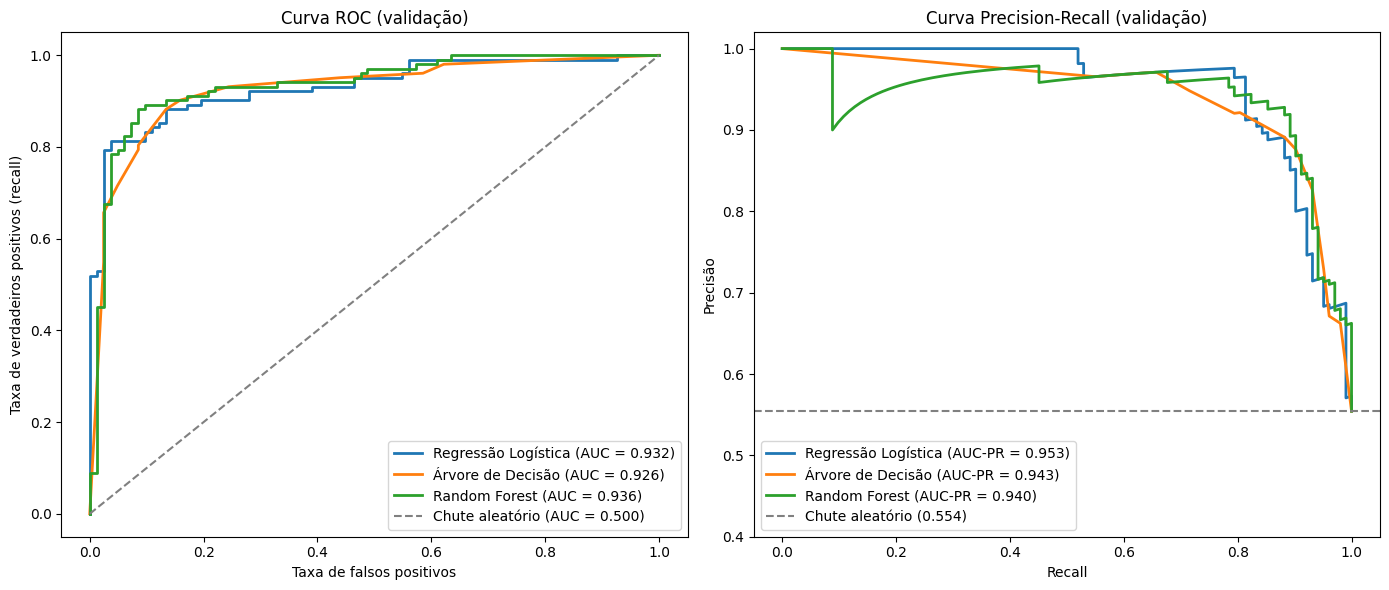

In [11]:
from sklearn.metrics import roc_curve

fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(14, 6))

for nome, busca in buscas.items():
    prob = prob_positiva(busca.best_estimator_, X_val)
    fpr, tpr, _ = roc_curve(y_val, prob, pos_label=1)
    precisoes, recalls, _ = precision_recall_curve(y_val, prob, pos_label=1)
    ax_roc.plot(fpr, tpr, linewidth=2, label=f"{nome} (AUC = {roc_auc_score(y_val, prob):.3f})")
    ax_pr.plot(recalls, precisoes, linewidth=2, label=f"{nome} (AUC-PR = {auc(recalls, precisoes):.3f})")

ax_roc.plot([0, 1], [0, 1], '--', color='gray', label='Chute aleatório (AUC = 0.500)')
ax_roc.set_title('Curva ROC (validação)')
ax_roc.set_xlabel('Taxa de falsos positivos')
ax_roc.set_ylabel('Taxa de verdadeiros positivos (recall)')
ax_roc.legend(loc='lower right')

proporcao_doentes = y_val.mean()
ax_pr.axhline(proporcao_doentes, linestyle='--', color='gray', label=f'Chute aleatório ({proporcao_doentes:.3f})')
ax_pr.set_title('Curva Precision-Recall (validação)')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precisão')
ax_pr.set_ylim(0.4, 1.02)
ax_pr.legend(loc='lower left')

plt.tight_layout()
plt.show()

**Como as áreas são calculadas e interpretadas:**

- **ROC-AUC:** área sob a curva ROC, calculada com `roc_auc_score`. Vai de
  0,5 (modelo que chuta, a linha tracejada) até 1,0 (modelo perfeito). É a
  chance de um doente sorteado receber probabilidade maior que um saudável
  sorteado: com 0,936, o Random Forest acerta essa ordem em ~94% dos pares.
- **AUC-PR (trapézio):** área sob a curva Precision-Recall, calculada com a
  função `auc`, que liga os pontos com retas e soma a área dos trapézios
  formados (integração trapezoidal). A referência de um modelo que chuta é
  a proporção de doentes (0,554 na validação, a linha tracejada). Ela é
  alta porque a base é balanceada; numa base como a de AVC seria ~0,05.
- **Average Precision (AP):** calculada com `average_precision_score`. Soma
  a precisão de cada ponto multiplicada pelo quanto o recall aumentou desde
  o ponto anterior, ou seja, soma degraus, sem ligar os pontos com retas.
  **AP não é a mesma coisa que AUC-PR por trapézio.** A diferença aparece
  na Árvore de Decisão: com só 13 probabilidades diferentes, a curva PR
  dela tem poucos pontos, e ligar pontos distantes com retas **superestima**
  a área (AUC-PR 0,943 contra AP 0,928). Por isso a AP é a forma mais
  confiável de resumir a curva PR.

**Leitura das curvas:**

- **ROC:** as três curvas praticamente se sobrepõem, o que confirma que os
  modelos estão muito próximos.
- **Precision-Recall:** no começo (recall baixo), a Regressão Logística
  fica acima: os ~50% de doentes com as probabilidades mais altas são todos
  doentes de fato (precisão 100%), e é isso que dá a ela a maior AP. O
  Random Forest tem uma queda logo no início (precisão 0,90 perto do recall
  0,1): um paciente saudável recebeu uma das probabilidades mais altas.
  Depois do recall ~0,6, as curvas se misturam.
- **O "arco" depois de uma queda:** logo depois de um falso positivo, a
  precisão cai; em seguida, enquanto só entram doentes, ela sobe devagar,
  porque VP aumenta e FP fica parado na conta VP / (VP + FP).
- A curva da **Árvore de Decisão** é feita de poucos segmentos retos, um
  para cada folha, justamente porque ela só tem 13 probabilidades
  diferentes.

### 7. Escolha dos cortes `t1` e `t2`

Primeiro definimos o que cada faixa **significa na prática** em um
consultório. O modelo funciona como uma **triagem**, não como diagnóstico:

| Faixa | O que acontece com o paciente | Erro possível | Gravidade |
|---|---|---|---|
| **Negativo automático** (`prob < t1`) | é liberado sem passar pelo cardiologista | doente liberado (**falso negativo**) | **muito grave**: a doença avança sem tratamento |
| **Análise manual** (`t1 ≤ prob < t2`) | cardiologista avalia o caso | nenhum automático (custo = tempo do médico) | - |
| **Positivo automático** (`prob ≥ t2`) | vai direto para exames confirmatórios (ecocardiograma, teste ergométrico...) | saudável faz exames à toa (**falso positivo**) | leve: custo e incômodo dos exames |

Como os dois erros têm gravidades bem diferentes, as tolerâncias são
diferentes, e foram fixadas **antes** de olhar os resultados:

- **`t1`:** no máximo **2% dos doentes reais** podem cair no negativo
  automático. Escolhemos o **maior** `t1` que respeita isso (quanto maior o
  `t1`, mais pacientes saudáveis são liberados sem ocupar o médico).
- **`t2`:** no máximo **5% dos saudáveis reais** podem cair no positivo
  automático. Escolhemos o **menor** `t2` que respeita isso (quanto menor o
  `t2`, mais doentes vão direto para os exames sem esperar pelo médico).

Os cortes candidatos vão de 5 em 5 pontos percentuais. Um ajuste mais fino
(de 1 em 1) acabaria "decorando" pacientes específicos da validação, que tem
só 184 pessoas.

Em termos de precisão e recall: o `t1` controla o **recall** da triagem
(quantos doentes são pegos antes de serem liberados), e o `t2` controla a
**precisão** do positivo automático (quantos dos encaminhados direto são de
fato doentes). Aqui aceitamos muito mais sacrificar a automação do que o
recall.

In [12]:
def proporcoes_de_erro(y_true, y_prob, t1, t2):
    """
    Aplica os cortes com assign_decision_band e devolve as duas proporções de
    erro automático do relatório, mais o tamanho de cada faixa.
    """
    y_true = np.asarray(y_true)
    faixa = assign_decision_band(y_prob, t1, t2)
    return {
        # denominador = total de POSITIVOS reais
        'positivos_perdidos': ((y_true == 1) & (faixa == 'negativo_automatico')).sum() / (y_true == 1).sum(),
        # denominador = total de NEGATIVOS reais
        'negativos_mal_classificados': ((y_true == 0) & (faixa == 'positivo_automatico')).sum() / (y_true == 0).sum(),
        'pct_negativo_automatico': (faixa == 'negativo_automatico').mean(),
        'pct_analise_manual': (faixa == 'analise_manual').mean(),
        'pct_positivo_automatico': (faixa == 'positivo_automatico').mean(),
    }


TOLERANCIA_POSITIVOS_PERDIDOS = 0.02   # t1: no máximo 2% dos doentes liberados
TOLERANCIA_NEGATIVOS_ERRADOS = 0.05    # t2: no máximo 5% dos saudáveis encaminhados à toa

cortes_candidatos = np.round(np.arange(0.05, 1.0, 0.05), 2)

# Cada corte é testado sozinho: "positivos perdidos" só depende de t1 e
# "negativos mal classificados" só depende de t2. O outro corte fica no extremo.
linhas = []
for corte in cortes_candidatos:
    como_t1 = proporcoes_de_erro(y_val, y_prob_val, t1=corte, t2=1.0)
    como_t2 = proporcoes_de_erro(y_val, y_prob_val, t1=0.0, t2=corte)
    linhas.append({
        'Corte': corte,
        'Se t1: % doentes liberados': como_t1['positivos_perdidos'] * 100,
        'Se t1: % população liberada': como_t1['pct_negativo_automatico'] * 100,
        'Se t2: % saudáveis encaminhados': como_t2['negativos_mal_classificados'] * 100,
        'Se t2: % população encaminhada': como_t2['pct_positivo_automatico'] * 100,
    })
tabela_cortes = pd.DataFrame(linhas)
display(tabela_cortes.round({c: 1 for c in tabela_cortes.columns if c != 'Corte'}))

t1 = tabela_cortes.loc[
    tabela_cortes['Se t1: % doentes liberados'] <= TOLERANCIA_POSITIVOS_PERDIDOS * 100, 'Corte'
].max()
t2 = tabela_cortes.loc[
    tabela_cortes['Se t2: % saudáveis encaminhados'] <= TOLERANCIA_NEGATIVOS_ERRADOS * 100, 'Corte'
].min()
assert t1 < t2, "as tolerâncias escolhidas deixaram t1 >= t2"

print(f"t1 escolhido = {t1:.2f}  |  t2 escolhido = {t2:.2f}")

,Corte,Se t1: % doentes liberados,Se t1: % população liberada,Se t2: % saudáveis encaminhados,Se t2: % população encaminhada
0,0.05,0.0,10.3,76.8,89.7
1,0.10,2.0,18.5,61.0,81.5
2,0.15,2.9,22.3,53.7,77.7
3,0.20,5.9,27.2,46.3,72.8
4,0.25,5.9,32.6,34.1,67.4
5,0.30,6.9,35.3,29.3,64.7
6,0.35,6.9,38.6,22.0,61.4
7,0.40,8.8,40.8,19.5,59.2
8,0.45,9.8,42.9,15.9,57.1
9,0.50,10.8,45.1,12.2,54.9


t1 escolhido = 0.10  |  t2 escolhido = 0.65


Na tabela dá para ver o dilema:

- **`t1 = 0,10`**: libera 18,5% da população sem médico, e 2 dos 102
  doentes da validação (1,96%) caem nessa faixa, no limite da tolerância.
  Subir para 0,15 liberaria mais ~4% da população, mas os doentes liberados
  iriam para 2,9%, acima do aceitável.
- **`t2 = 0,65`**: 3,7% dos saudáveis (3 de 82) iriam fazer exames à toa.
  Descer para 0,60 encaminharia mais pacientes direto, mas esse número
  subiria para 6,1%, acima dos 5%.

O histograma abaixo mostra a mesma decisão na **validação** (é esta a
visualização usada para escolher os cortes; o resultado final vem só no
teste, na seção 9):

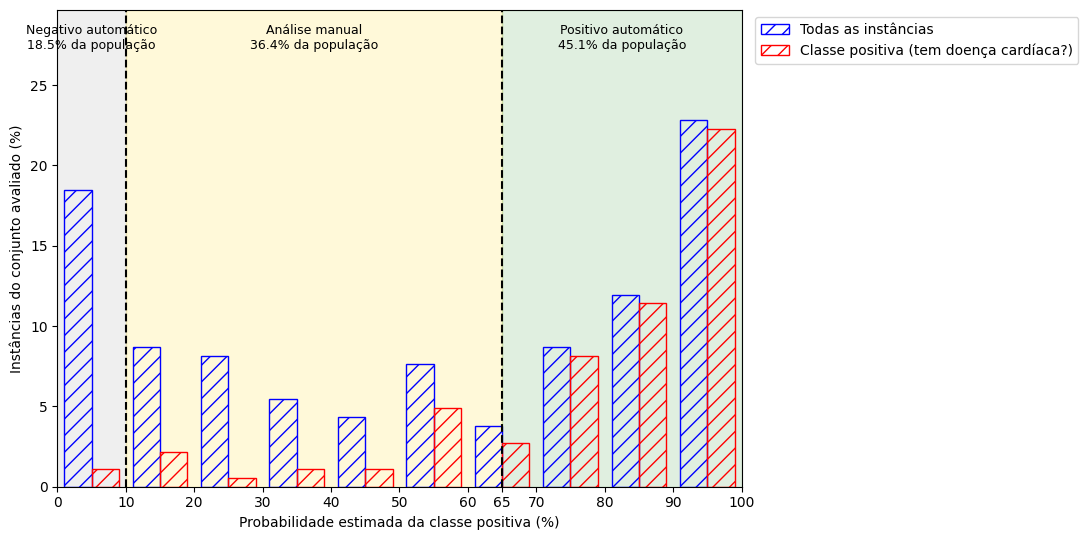

In [13]:
fig, ax = plot_histogram(
    y_val, y_prob_val, t1=t1, t2=t2,
    positive_class_definition="tem doença cardíaca?",
    bin_width_pct=10,
)

**Leitura do histograma (validação):**

- Na faixa de 0-10% a barra vermelha é mínima (2 doentes entre 34
  pacientes): o modelo tem bastante certeza sobre esses pacientes
  saudáveis, por isso eles podem ser liberados automaticamente.
- Nas faixas de 70-100% quase toda a barra azul é vermelha: são os doentes
  que o modelo identifica com segurança.
- No meio (10-65%) azul e vermelho se misturam. É onde o modelo "não sabe",
  e é exatamente a faixa que mandamos para o cardiologista.

Como a base é **balanceada**, a barra vermelha é grande em todo o lado
direito do gráfico. Numa base desbalanceada (ex.: AVC com ~5% de
positivos), a barra vermelha seria pequena em todo o gráfico e o desafio
seria achar os poucos positivos no meio de muitos negativos.

### 8. Comparando cenários de corte (validação)

Para justificar a escolha, comparamos o cenário escolhido com duas
alternativas extremas, sempre na validação:

- **Máxima automação** (`t1 = 0,45`, `t2 = 0,55`): quase ninguém vai para o
  médico. É o que aconteceria usando praticamente só o corte padrão de 0,5.
- **Escolhido** (`t1`, `t2` da seção 7).
- **Ultra conservador** (`t1 = 0,05`, `t2 = 0,90`): só automatiza quando o
  modelo tem quase certeza.

In [14]:
cenarios = {
    'Máxima automação': (0.45, 0.55),
    'Escolhido': (t1, t2),
    'Ultra conservador': (0.05, 0.90),
}

linhas = []
for nome, (c1, c2) in cenarios.items():
    r = proporcoes_de_erro(y_val, y_prob_val, c1, c2)
    linhas.append({
        'Cenário': nome,
        't1': c1,
        't2': c2,
        '% negativo automático': r['pct_negativo_automatico'] * 100,
        '% análise manual': r['pct_analise_manual'] * 100,
        '% positivo automático': r['pct_positivo_automatico'] * 100,
        '% doentes liberados (÷ positivos)': r['positivos_perdidos'] * 100,
        '% saudáveis encaminhados (÷ negativos)': r['negativos_mal_classificados'] * 100,
    })
tabela_cenarios = pd.DataFrame(linhas)
display(tabela_cenarios.round({c: 1 for c in tabela_cenarios.columns if c not in ('t1', 't2')}))

,Cenário,t1,t2,% negativo automático,% análise manual,% positivo automático,% doentes liberados (÷ positivos),% saudáveis encaminhados (÷ negativos)
0,Máxima automação,0.45,0.55,42.9,3.8,53.3,9.8,9.8
1,Escolhido,0.10,0.65,18.5,36.4,45.1,2.0,3.7
2,Ultra conservador,0.05,0.90,10.3,66.8,22.8,0.0,1.2


**Conclusão da comparação:**

- **Máxima automação**: o médico só vê ~4% dos pacientes, mas **1 em cada
  10 doentes** é mandado para casa como saudável. Em cardiologia isso é
  inaceitável.
- **Ultra conservador**: nenhum doente é liberado, mas **2 de cada 3
  pacientes** voltam para o médico e o modelo quase não ajuda. Para evitar
  os 2 doentes liberados do cenário escolhido, o médico teria que avaliar
  quase o dobro de pacientes.
- **Escolhido**: fica dentro das duas tolerâncias e automatiza quase 2/3
  dos casos (18,5% liberados sem médico + 45,1% direto para os exames).

O preço é que pouco mais de 1/3 dos pacientes ainda precisa de análise
manual. Nesse domínio, preferimos pagar com tempo de médico a pagar com
doentes sem tratamento.

### 9. Resultado final no conjunto de teste

A partir daqui usamos o conjunto de teste, que não foi usado em nenhuma
decisão até agora. O modelo e os cortes estão **congelados**:

- **Modelo final:** Random Forest com 300 árvores, `max_depth = 5`,
  `min_samples_leaf = 4`, `min_samples_split = 5`, `max_features = "sqrt"`,
  `criterion = "gini"` e `random_state = 42`, treinado no conjunto de
  treino.
- **Cortes:** `t1` e `t2` da seção 7.

Primeiro as métricas gerais e as curvas (com o corte padrão de 0,5 nas
métricas que precisam de decisão sim/não); depois, o que interessa para o
trabalho: as faixas de decisão.

In [15]:
y_prob_test = prob_positiva(melhor_modelo, X_test)

display(pd.DataFrame.from_dict(
    {f'{nome_melhor} (teste)': avaliar(melhor_modelo, X_test, y_test)}, orient='index'
).round(4))

,Acurácia,Precisão,Recall,F1,ROC-AUC,AUC-PR (trapézio),AP,VP,FP,FN,VN
Random Forest (teste),0.8641,0.8532,0.9118,0.8815,0.934,0.9398,0.9402,93,16,9,66


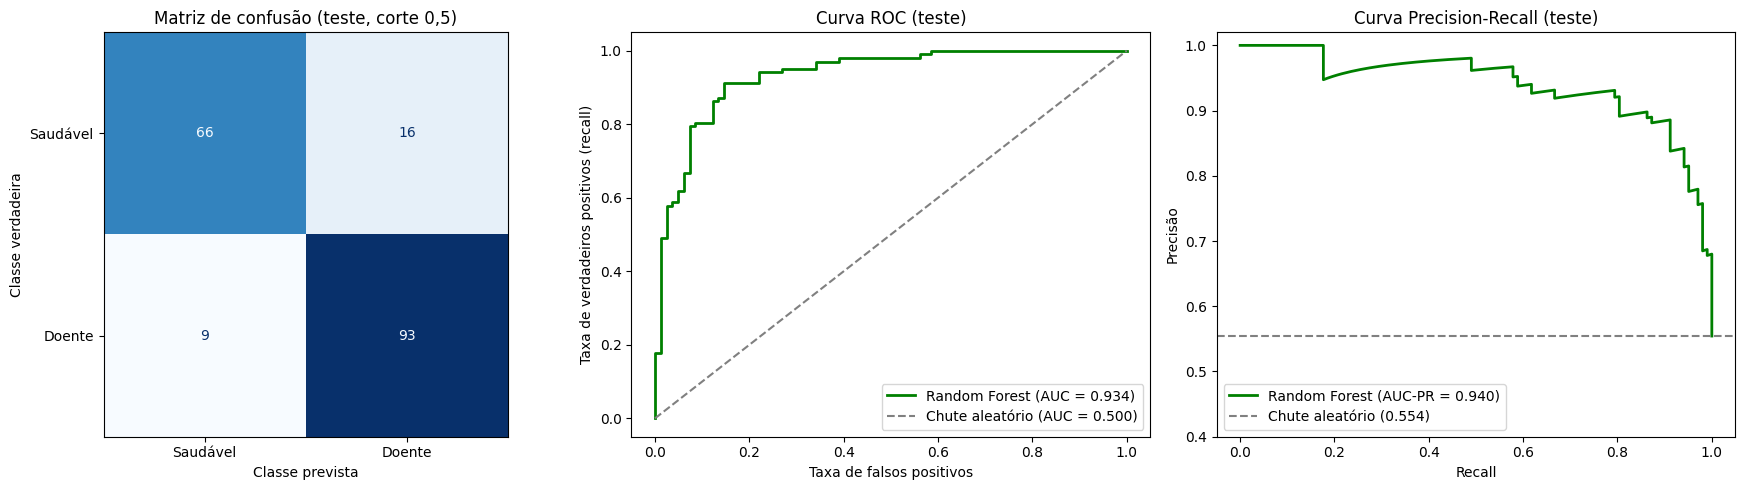

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, (ax_mc, ax_roc, ax_pr) = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, (y_prob_test >= LIMIAR_PADRAO).astype(int), labels=[0, 1],
    display_labels=['Saudável', 'Doente'], cmap='Blues', colorbar=False, ax=ax_mc,
)
ax_mc.set_title('Matriz de confusão (teste, corte 0,5)')
ax_mc.set_xlabel('Classe prevista')
ax_mc.set_ylabel('Classe verdadeira')

fpr, tpr, _ = roc_curve(y_test, y_prob_test, pos_label=1)
ax_roc.plot(fpr, tpr, linewidth=2, color='green',
            label=f'{nome_melhor} (AUC = {roc_auc_score(y_test, y_prob_test):.3f})')
ax_roc.plot([0, 1], [0, 1], '--', color='gray', label='Chute aleatório (AUC = 0.500)')
ax_roc.set_title('Curva ROC (teste)')
ax_roc.set_xlabel('Taxa de falsos positivos')
ax_roc.set_ylabel('Taxa de verdadeiros positivos (recall)')
ax_roc.legend(loc='lower right')

precisoes, recalls, _ = precision_recall_curve(y_test, y_prob_test, pos_label=1)
ax_pr.plot(recalls, precisoes, linewidth=2, color='green',
           label=f'{nome_melhor} (AUC-PR = {auc(recalls, precisoes):.3f})')
ax_pr.axhline(y_test.mean(), linestyle='--', color='gray', label=f'Chute aleatório ({y_test.mean():.3f})')
ax_pr.set_title('Curva Precision-Recall (teste)')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precisão')
ax_pr.set_ylim(0.4, 1.02)
ax_pr.legend(loc='lower left')

plt.tight_layout()
plt.show()

- **ROC-AUC de 0,934 no teste**, contra 0,936 na validação: o modelo
  generaliza para pacientes que nunca viu, não decorou o treino.
- **Matriz de confusão com o corte único de 0,5:** 93 doentes e 66
  saudáveis classificados corretamente, 16 saudáveis dados como doentes
  (falsos positivos) e **9 doentes dados como saudáveis** (falsos
  negativos). Ou seja, com um corte único, 9 dos 102 doentes (8,8%) seriam
  mandados para casa.
- As faixas de decisão resolvem isso, como mostra a próxima etapa.

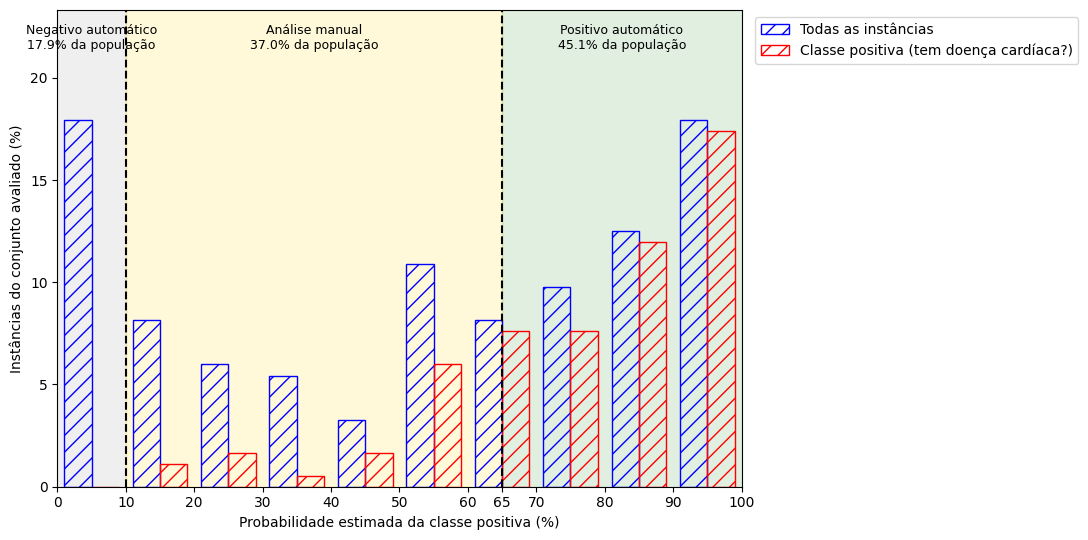

Relatório por faixa de decisão (conjunto de teste):


,Faixa,Instâncias,% da população (n / total_teste),Positivos reais,% positivos na faixa (pos / n),Negativos reais,% negativos na faixa (neg / n)
0,negativo_automatico,33,17.93,0,0.00,33,100.00
1,analise_manual,68,36.96,25,36.76,43,63.24
2,positivo_automatico,83,45.11,77,92.77,6,7.23



Positivos reais classificados automaticamente como negativos: 0/102 (0.00%; denominador = total de positivos reais)
Negativos reais classificados automaticamente como positivos: 6/82 (7.32%; denominador = total de negativos reais)


In [17]:
fig, ax = plot_histogram(
    y_test, y_prob_test, t1=t1, t2=t2,
    positive_class_definition="tem doença cardíaca?",
    bin_width_pct=10,
)

tabela_teste = decision_band_report(y_test, y_prob_test, t1=t1, t2=t2)

In [18]:
# Validação x teste: se os números forem parecidos, os cortes generalizam
comparacao = pd.DataFrame([
    {'Conjunto': 'Validação', 'ROC-AUC': roc_auc_score(y_val, y_prob_val),
     **{k: v * 100 for k, v in proporcoes_de_erro(y_val, y_prob_val, t1, t2).items()}},
    {'Conjunto': 'Teste', 'ROC-AUC': roc_auc_score(y_test, y_prob_test),
     **{k: v * 100 for k, v in proporcoes_de_erro(y_test, y_prob_test, t1, t2).items()}},
])
display(comparacao.round(2))

,Conjunto,ROC-AUC,positivos_perdidos,negativos_mal_classificados,pct_negativo_automatico,pct_analise_manual,pct_positivo_automatico
0,Validação,0.94,1.96,3.66,18.48,36.41,45.11
1,Teste,0.93,0.00,7.32,17.93,36.96,45.11


**Leitura do resultado no teste:**

- **Tamanho das faixas** praticamente idêntico ao da validação (≈18% /
  37% / 45%): a divisão de trabalho entre modelo e médico se mantém.
- **Doentes liberados automaticamente: 0 de 102.** Com o corte único de
  0,5 eram 9; com as faixas, o erro grave, que era a nossa prioridade, não
  aconteceu no teste. Todos os 33 pacientes liberados eram de fato
  saudáveis.
- **Saudáveis encaminhados à toa: 6 de 82 (7,3%)**, acima da tolerância de
  5% que tinha sido atingida na validação (3 de 82). A diferença é de 3
  pacientes: com só 82 saudáveis em cada conjunto, cada paciente vale ~1,2
  ponto percentual, então os percentuais oscilam bastante de um conjunto
  para o outro. Esse é o erro **barato** (exames a mais), justamente o que
  aceitamos tolerar mais.
- **Não reajustamos o `t2` depois de ver o teste.** Se fizéssemos isso,
  estaríamos escolhendo o corte com o teste, e ele deixaria de ser uma
  medida honesta. O resultado correto a reportar é este: com os cortes
  escolhidos na validação, o sistema não deixou nenhum doente escapar e
  encaminhou 7,3% dos saudáveis para exames desnecessários.

### 10. Quais características mais pesam na decisão (SHAP)

Assim como no notebook do spam, usamos o SHAP para ver quais atributos
empurram a probabilidade para cima (doença) ou para baixo (saudável).

- **Saída explicada:** a probabilidade de doença cardíaca (classe 1)
  estimada pelo Random Forest.
- **Dados usados:** os 184 pacientes do conjunto de teste, já
  pré-processados (numéricos com os ausentes preenchidos e categóricos em
  colunas 0/1).
- **Explicador:** `TreeExplainer`, próprio para modelos de árvores.

Como ler o gráfico: cada ponto é um paciente; a posição mostra quanto
aquele atributo aumentou (direita) ou diminuiu (esquerda) a probabilidade
de doença; a cor indica se o valor do atributo é alto (vermelho) ou baixo
(azul). Os atributos estão ordenados do mais importante para o menos
importante.

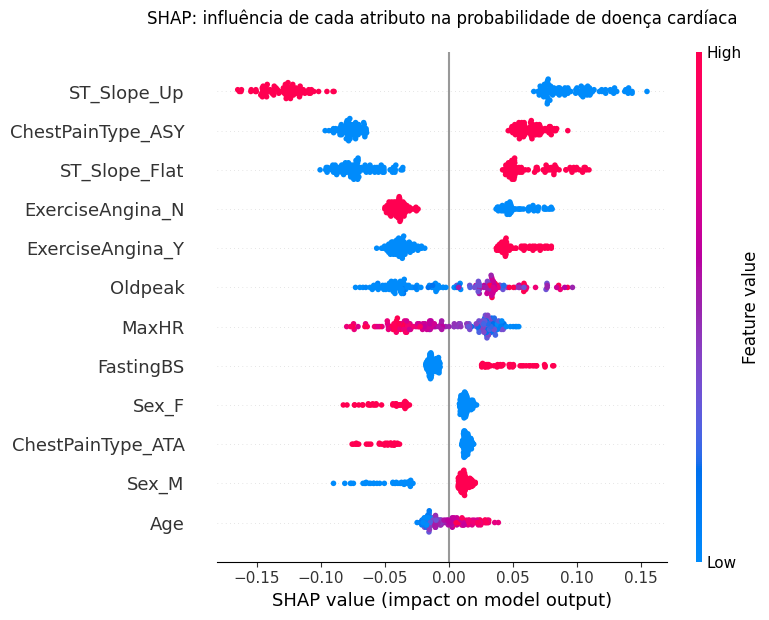

In [19]:
import warnings
warnings.filterwarnings('ignore', message='IProgress not found')  # aviso visual do tqdm, não afeta o cálculo
import shap

# O SHAP explica o Random Forest, que recebe os dados já pré-processados
preprocessador_treinado = melhor_modelo.named_steps['preprocessamento']
floresta = melhor_modelo.named_steps['modelo']

X_test_transformado = pd.DataFrame(
    preprocessador_treinado.transform(X_test),
    columns=[
        nome.replace('numericos__', '').replace('categoricos__', '')
        for nome in preprocessador_treinado.get_feature_names_out()
    ],
)

explainer = shap.TreeExplainer(floresta)
valores_shap = explainer(X_test_transformado)

# Em classificação binária o SHAP pode devolver uma dimensão por classe: ficamos com a classe 1
if valores_shap.values.ndim == 3:
    valores_positivo = valores_shap.values[:, :, indice_positivo]
else:
    valores_positivo = valores_shap.values

shap.summary_plot(valores_positivo, X_test_transformado, max_display=12, show=False)
plt.title("SHAP: influência de cada atributo na probabilidade de doença cardíaca", pad=20)
plt.tight_layout()
plt.show()

Os atributos que mais pesam fazem sentido clínico:

- **`ST_Slope_Up`** (inclinação ascendente do segmento ST no esforço) é o
  padrão de um coração saudável e puxa a probabilidade para baixo; o
  segmento ST plano (`ST_Slope_Flat`) puxa para cima.
- **`ChestPainType_ASY`** (dor no peito assintomática): é justamente a
  categoria com mais doentes na base (79%), porque a doença coronária muitas
  vezes não dá a dor "típica".
- **`Oldpeak`** alto (depressão do segmento ST) e **`ExerciseAngina_Y`**
  (angina durante esforço) aumentam a probabilidade.
- **`MaxHR`** baixo (frequência cardíaca máxima mais baixa no teste de
  esforço) e **`FastingBS = 1`** (glicemia em jejum alta) aumentam a
  probabilidade.
- **`Sex_F`** reduz a probabilidade: na base, 26% das mulheres têm doença
  cardíaca contra 63% dos homens.

O **colesterol ficou fora** dos 12 atributos mais importantes (é o 13º, com
pouco peso). Isso confirma que o tratamento da seção 1 funcionou: sem ele,
o zero de colesterol seria um "atalho" forte para a classe positiva e o
modelo estaria aprendendo um artefato da coleta, não um sinal médico.

### 11. Conclusão do caso Heart Failure (base balanceada)

- **Base balanceada (55% / 45%)**: a acurácia é confiável e não foi
  preciso usar `class_weight` nem gerar dados sintéticos; os modelos já
  veem exemplos suficientes das duas classes.
- **Comparação de algoritmos**: Random Forest e Regressão Logística
  empataram na validação cruzada e ficaram muito próximos na validação; a
  Árvore de Decisão sozinha ficou atrás e dá poucas probabilidades
  diferentes. O Random Forest foi escolhido pela maior ROC-AUC na
  validação.
- **Balanceamento ≠ custo do erro**: mesmo com classes equilibradas, o
  falso negativo (doente liberado) é muito mais grave que o falso positivo
  (exame a mais). Por isso os cortes são **assimétricos**: `t1` bem baixo e
  tolerância de 2% para doentes perdidos, contra 5% para saudáveis
  encaminhados.
- **Resultado no teste**: com um corte único de 0,5, 9 dos 102 doentes
  seriam liberados. Com as faixas, o sistema automatiza 63% dos pacientes
  (18% liberados + 45% encaminhados direto), **nenhum doente foi liberado**
  e 37% vão para o cardiologista. O custo foi 7,3% dos saudáveis fazendo
  exames a mais, acima da meta de 5%, mas no tipo de erro menos grave.
- **Contraste com a base desbalanceada**: aqui a dificuldade não é achar a
  classe rara, e sim decidir **quanto** automatizar dado que os erros têm
  custos diferentes. No caso desbalanceado, o problema principal é o modelo
  nem enxergar os positivos.

**Limitações:**

- A validação e o teste têm 184 pacientes cada; um único paciente muda os
  percentuais em ~1 ponto (foi o que fez o `t2` passar da tolerância no
  teste). Com mais dados, ou escolhendo os cortes com validação cruzada, os
  cortes seriam mais estáveis.
- Random Forest e Regressão Logística ficaram praticamente empatados; com
  outra divisão dos dados, a Regressão Logística poderia ter sido a
  escolhida.
- Os dados vêm de hospitais das décadas de 1980/90 e juntam 5 bases com
  protocolos diferentes (o colesterol zerado é um sintoma disso). É um
  exercício de análise, não um sistema pronto para uso clínico.

# Parte 2
## Domínio: Predição de AVC (Stroke)

**Fonte da base:** [Stroke Prediction Dataset — Kaggle](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset) (autor: fedesoriano)

**Licença:** Data Files © Original Authors — disponibilizada publicamente no Kaggle para uso educacional/acadêmico.

**Variável-alvo:** `stroke` (0 = não teve AVC, 1 = teve AVC).

**Classe positiva:** "o paciente teve um AVC (stroke = 1)?" — é a classe rara e clinicamente mais importante de identificar.

Este notebook cobre: (1) exploração e balanceamento da base, (2) separação treino/validação/teste, (3) pré-processamento sem vazamento de dados, (4) comparação de 3 algoritmos com ajuste de hiperparâmetros via validação cruzada, (5) avaliação completa no conjunto de teste, (6) explicabilidade com SHAP e (7) aplicação do programa de pontos de corte (Parte 1) desenvolvido pelo colega de equipe.

In [18]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score, confusion_matrix,
                              roc_curve, precision_recall_curve)
import shap
import joblib

pd.set_option('display.max_columns', None)

## 1. Carregamento dos dados

In [19]:
df = pd.read_csv('./data/healthcare-dataset-stroke-data.csv')
df = df.drop(columns=['id'])  # identificador não é uma feature preditiva
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 2. Balanceamento das classes

Antes de qualquer modelagem, é preciso saber o quão raro é o evento que queremos prever. Isso muda completamente a forma como interpretamos accuracy e como escolhemos a métrica de otimização mais à frente.

In [20]:
contagem = df['stroke'].value_counts()
percentual = df['stroke'].value_counts(normalize=True) * 100
resumo_balanceamento = pd.DataFrame({'Quantidade': contagem, 'Percentual (%)': percentual.round(2)})
resumo_balanceamento

,Quantidade,Percentual (%)
stroke,,
0,4861,95.13
1,249,4.87


A base é **extremamente desbalanceada**: apenas ~4,9% dos pacientes tiveram AVC. Isso tem duas consequências diretas:

- **Accuracy é enganosa aqui.** Um modelo "preguiçoso" que sempre prevê "não teve AVC" já acertaria ~95% dos casos sem aprender nada útil.
- **A métrica de otimização precisa considerar isso.** Vamos usar **AUC-PR (Average Precision)** como métrica-alvo para escolher hiperparâmetros e comparar modelos, porque ela é sensível ao desempenho na classe rara (positiva) — diferente da accuracy, que é dominada pela classe majoritária. AUC-ROC também será reportada, mas de forma complementar, pois em bases muito desbalanceadas ela tende a parecer "otimista".

Além disso, o **custo dos erros não é simétrico**: um falso negativo (dizer que o paciente não terá AVC quando na verdade terá) é muito mais grave clinicamente do que um falso positivo (encaminhar por engano alguém saudável para revisão). Isso vai justificar, mais adiante, o uso de `class_weight='balanced'` nos modelos e a escolha dos pontos de corte t1/t2.

## 3. Separação treino / validação / teste

Usamos uma divisão explícita em três conjuntos, estratificada pela variável-alvo (para manter a mesma proporção de casos positivos em todos):

- **Treino (60%)** — usado para ajustar os modelos, com validação cruzada interna para otimizar hiperparâmetros.
- **Validação (20%)** — usado para comparar os modelos já otimizados, escolher o melhor, e escolher os pontos de corte t1/t2 da Parte 1.
- **Teste (20%)** — reservado e usado **apenas uma vez**, no final, para reportar o desempenho real do modelo escolhido.

In [21]:
num_cols = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

X = df.drop(columns=['stroke'])
y = df['stroke']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Treino:    {len(X_train):4d} instâncias | {y_train.mean()*100:.2f}% positivos")
print(f"Validação: {len(X_val):4d} instâncias | {y_val.mean()*100:.2f}% positivos")
print(f"Teste:     {len(X_test):4d} instâncias | {y_test.mean()*100:.2f}% positivos")

Treino:    3066 instâncias | 4.86% positivos
Validação: 1022 instâncias | 4.89% positivos
Teste:     1022 instâncias | 4.89% positivos


## 4. Pré-processamento (sem vazamento de dados)

O único valor faltante da base é em `bmi`. Em vez de preencher com a média da base inteira (o que vazaria informação do teste/validação para o treino), usamos um `SimpleImputer` **dentro de um `Pipeline`**: a média é calculada exclusivamente com os dados de treino em cada ajuste (inclusive dentro de cada fold da validação cruzada), e depois aplicada aos demais conjuntos.

As variáveis categóricas são transformadas com One-Hot Encoding, também ajustado apenas no treino. Para a Regressão Logística, aplicamos ainda um `StandardScaler` (modelos baseados em árvore não precisam de padronização).
Duas observações sobre as categóricas: `smoking_status` tem 1.544 linhas (~30%) com o valor `Unknown`, que mantivemos como uma categoria própria (não é valor ausente do pandas e apagar essas linhas removeria 30% da base); e `gender` tem uma única linha `Other`, que não influencia o resultado.

In [22]:
preprocess_tree = ColumnTransformer([
    ('num', SimpleImputer(strategy='mean'), num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
])

preprocess_scaled = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='mean')),
                       ('scaler', StandardScaler())]), num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
])

## 5. Treinamento e comparação de 3 algoritmos

Comparamos três algoritmos com naturezas diferentes: um modelo linear (Regressão Logística), um ensemble de árvores por bagging (Random Forest) e um ensemble de árvores por boosting (Hist Gradient Boosting). Todos usam `class_weight='balanced'` para compensar o desbalanceamento no treinamento.

Os hiperparâmetros de cada um são otimizados por **validação cruzada estratificada (5 folds) dentro do conjunto de treino**, usando **AUC-PR (average precision)** como métrica-alvo — justificada na seção 2 pelo desbalanceamento da base.

In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos_config = {
    'Regressão Logística': (
        Pipeline([('prep', preprocess_scaled),
                  ('clf', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42))]),
        {'clf__C': [0.01, 0.1, 1, 10]}
    ),
    'Random Forest': (
        Pipeline([('prep', preprocess_tree),
                  ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))]),
        {'clf__n_estimators': [200, 400], 'clf__max_depth': [4, 8, None]}
    ),
    'Hist Gradient Boosting': (
        Pipeline([('prep', preprocess_tree),
                  ('clf', HistGradientBoostingClassifier(class_weight='balanced', random_state=42))]),
        {'clf__max_depth': [3, 6, None], 'clf__learning_rate': [0.05, 0.1]}
    ),
}

modelos_treinados = {}
resultados = []

for nome, (pipe, grid) in modelos_config.items():
    busca = GridSearchCV(pipe, grid, scoring='average_precision', cv=cv, n_jobs=-1)
    busca.fit(X_train, y_train)
    modelos_treinados[nome] = busca.best_estimator_

    prob_val = busca.best_estimator_.predict_proba(X_val)[:, 1]
    pred_val = (prob_val >= 0.5).astype(int)  # limiar de 0.5 usado para as métricas de decisão

    resultados.append({
        'Modelo': nome,
        'Melhores hiperparâmetros': busca.best_params_,
        'AP (CV no treino)': round(busca.best_score_, 4),
        'Acurácia (val)': round(accuracy_score(y_val, pred_val), 4),
        'Precisão (val)': round(precision_score(y_val, pred_val), 4),
        'Recall (val)': round(recall_score(y_val, pred_val), 4),
        'F1 (val)': round(f1_score(y_val, pred_val), 4),
        'AUC-ROC (val)': round(roc_auc_score(y_val, prob_val), 4),
        'AUC-PR (val)': round(average_precision_score(y_val, prob_val), 4),
    })

tabela_comparativa = pd.DataFrame(resultados)
tabela_comparativa

,Modelo,Melhores hiperparâmetros,AP (CV no treino),Acurácia (val),Precisão (val),Recall (val),F1 (val),AUC-ROC (val),AUC-PR (val)
0,Regressão Logística,{'clf__C': 0.1},0.2119,0.7172,0.1254,0.80,0.2168,0.8397,0.1934
1,Random Forest,"{'clf__max_depth': 4, 'clf__n_estimators': 200}",0.1822,0.6585,0.1117,0.86,0.1977,0.8346,0.1881
2,Hist Gradient Boosting,"{'clf__learning_rate': 0.05, 'clf__max_depth': 3}",0.1873,0.7016,0.1217,0.82,0.2119,0.8254,0.1840


> **Nota sobre o limiar:** accuracy, precisão, recall e F1 dependem de uma decisão binária, então usamos o limiar padrão de **0,5** sobre a probabilidade estimada para calculá-las nesta etapa de comparação. AUC-ROC e AUC-PR, por outro lado, **não dependem de um limiar fixo** — elas resumem o desempenho do modelo variando esse limiar de 0 a 1 e medindo a área sob a curva resultante (ROC: taxa de verdadeiros positivos x taxa de falsos positivos; PR: precisão x recall). É exatamente essa variação de limiar que gera as curvas plotadas mais abaixo.

## 6. Escolha do melhor modelo

Selecionamos o melhor modelo com base no **AUC-PR sobre o conjunto de validação** — a métrica mais adequada dado o desbalanceamento discutido na seção 2.
**Ressalva:** as diferenças entre os três modelos são pequenas (AUC-PR na validação: Regressão Logística 0,193, Random Forest 0,188, Hist Gradient Boosting 0,184; e na validação cruzada do treino 0,212, 0,182 e 0,187). Com apenas 50 casos positivos na validação, isso é quase um empate técnico: a Regressão Logística foi a escolhida pelo critério definido, mas não dá para afirmar que ela é claramente superior. Um ponto a favor dela é ser o modelo mais simples e interpretável.

In [24]:
melhor_nome = tabela_comparativa.sort_values('AUC-PR (val)', ascending=False).iloc[0]['Modelo']
melhor_modelo = modelos_treinados[melhor_nome]
print(f"Melhor modelo: {melhor_nome}")
print(f"Hiperparâmetros: {modelos_treinados[melhor_nome].named_steps['clf'].get_params()}")

Melhor modelo: Regressão Logística
Hiperparâmetros: {'C': 0.1, 'class_weight': 'balanced', 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 2000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


## 7. Avaliação final no conjunto de TESTE

Esta é a única vez em que tocamos no conjunto de teste. Nenhum ajuste é feito a partir daqui — apenas medição do desempenho final do modelo escolhido.

In [25]:
prob_test = melhor_modelo.predict_proba(X_test)[:, 1]
pred_test = (prob_test >= 0.5).astype(int)

metricas_teste = {
    'Acurácia': accuracy_score(y_test, pred_test),
    'Precisão': precision_score(y_test, pred_test),
    'Recall': recall_score(y_test, pred_test),
    'F1-score': f1_score(y_test, pred_test),
    'AUC-ROC': roc_auc_score(y_test, prob_test),
    'AUC-PR (Average Precision)': average_precision_score(y_test, prob_test),
}

print(f"--- Desempenho final de '{melhor_nome}' no conjunto de TESTE (limiar = 0.5) ---")
for k, v in metricas_teste.items():
    print(f"{k}: {v:.4f}")

print("\nMatriz de confusão (linhas = real, colunas = previsto) [0, 1]:")
print(confusion_matrix(y_test, pred_test))

--- Desempenho final de 'Regressão Logística' no conjunto de TESTE (limiar = 0.5) ---
Acurácia: 0.7299
Precisão: 0.1258
Recall: 0.7600
F1-score: 0.2159
AUC-ROC: 0.8033
AUC-PR (Average Precision): 0.2165

Matriz de confusão (linhas = real, colunas = previsto) [0, 1]:
[[708 264]
 [ 12  38]]


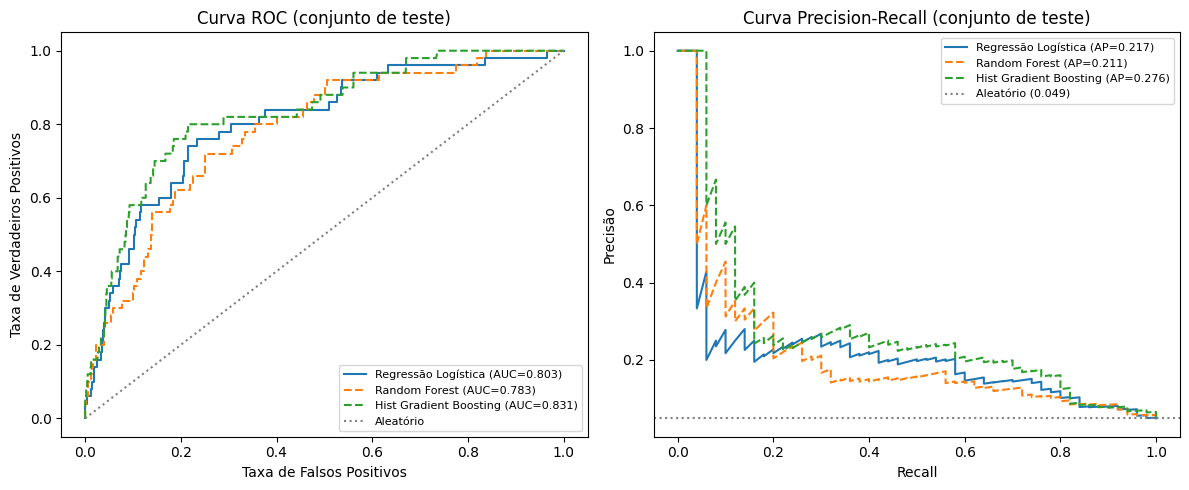

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for nome, modelo in modelos_treinados.items():
    prob = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    prec, rec, _ = precision_recall_curve(y_test, prob)
    estilo = '-' if nome == melhor_nome else '--'
    axes[0].plot(fpr, tpr, estilo, label=f"{nome} (AUC={roc_auc_score(y_test, prob):.3f})")
    axes[1].plot(rec, prec, estilo, label=f"{nome} (AP={average_precision_score(y_test, prob):.3f})")

axes[0].plot([0, 1], [0, 1], ':', color='gray', label='Aleatório')
axes[0].set_xlabel('Taxa de Falsos Positivos'); axes[0].set_ylabel('Taxa de Verdadeiros Positivos')
axes[0].set_title('Curva ROC (conjunto de teste)'); axes[0].legend(fontsize=8)

taxa_base = y_test.mean()
axes[1].axhline(taxa_base, linestyle=':', color='gray', label=f'Aleatório ({taxa_base:.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precisão')
axes[1].set_title('Curva Precision-Recall (conjunto de teste)'); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

**Leitura do desempenho no teste (limiar = 0,5):**

- **Acurácia de 73%** é menor que a de um modelo que sempre responde "não teve AVC" (~95,1% no teste). Esse é exatamente o caso da seção 2: a acurácia sozinha não serve aqui e não deve ser usada para avaliar o modelo.
- **Recall de 76%** (38 de 50 AVCs identificados) e **12 AVCs não detectados** com o limiar de 0,5.
- **Precisão de 12,6%**: dos 302 pacientes que o modelo sinalizou, só 38 tiveram AVC (cerca de 1 em cada 8). São 264 falsos positivos. Esse é o preço de priorizar o recall em uma classe rara.
- **AUC-ROC de 0,80** no teste (0,84 na validação) e **AUC-PR (AP) de 0,217**, cerca de 4,4 vezes a taxa base (~4,9%): o modelo ordena os pacientes de forma útil, mas está longe de ser um classificador preciso.

Conclusão: o modelo serve como **triagem para priorizar quem revisar**, e não como diagnóstico.

As curvas são construídas variando o limiar de decisão de 1 até 0: em cada ponto, calcula-se a taxa de falsos positivos e verdadeiros positivos (ROC) ou a precisão e o recall (PR) resultantes daquele limiar. A **AUC-ROC** é a área sob a curva ROC (0,5 = aleatório, 1,0 = perfeito). A **AUC-PR** (aqui calculada como *Average Precision*, uma soma ponderada das precisões a cada novo verdadeiro positivo encontrado — distinta da integração trapezoidal pura da curva PR, embora ambas aproximem a mesma área) é mais informativa em bases desbalanceadas, pois o nível de referência "aleatório" é a própria taxa de positivos da base (~4,9%), e não 0,5 como na ROC.

## 8. Explicabilidade (SHAP)

Usamos SHAP para entender quais variáveis mais influenciam a saída do modelo, calculado sobre as instâncias do **conjunto de teste**.

**Unidade:** como o modelo escolhido é a Regressão Logística (explicada com `LinearExplainer`), os valores SHAP estão em **log-odds** (a escala linear da regressão logística), e **não em probabilidade**. Por isso o eixo do gráfico vai de aproximadamente −3,5 a +3,5. Valor positivo significa que a característica aumenta o escore de risco do paciente; valor negativo, que diminui. A relação com a probabilidade é monotônica (mais log-odds = mais probabilidade), mas não é linear.

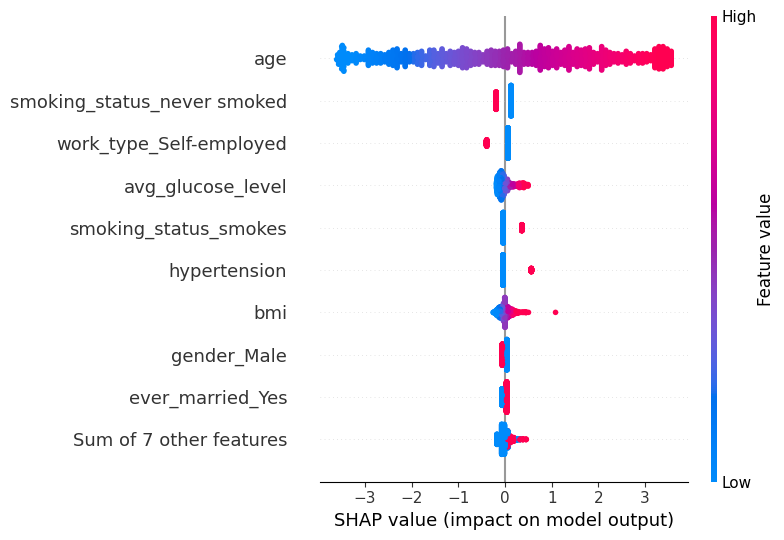

In [27]:
prep_ajustado = melhor_modelo.named_steps['prep']
clf_ajustado = melhor_modelo.named_steps['clf']

X_train_transf = prep_ajustado.transform(X_train)
X_test_transf = prep_ajustado.transform(X_test)
nomes_features = [c.split('__', 1)[-1] for c in prep_ajustado.get_feature_names_out()]

if hasattr(clf_ajustado, 'coef_'):
    explainer = shap.LinearExplainer(clf_ajustado, X_train_transf)
else:
    explainer = shap.TreeExplainer(clf_ajustado)

valores_shap = explainer(X_test_transf)
valores_shap.feature_names = nomes_features

shap.plots.beeswarm(valores_shap, show=False)
plt.tight_layout()
plt.show()

**Leitura do gráfico:** cada ponto é um paciente do conjunto de teste; a posição no eixo X mostra quanto aquela característica empurrou o escore de risco daquele paciente para cima (direita) ou para baixo (esquerda), e a cor mostra se o valor da característica era alto (vermelho) ou baixo (azul). No caso das variáveis binárias (0/1), vermelho = 1 (a condição está presente).

O que o gráfico mostra:

- **`age` domina de longe.** Os pontos vão de cerca de −3,5 a +3,5 e a cor é bem ordenada: idade alta (vermelho) puxa para cima e idade baixa (azul) puxa para baixo. É coerente com o conhecimento clínico de que o risco de AVC cresce com a idade.
- **`avg_glucose_level`** (4ª) e **`hypertension`** também aumentam o escore quando altos/presentes, no sentido esperado clinicamente, mas com efeito bem menor que a idade. **`smoking_status_smokes`** e **`bmi`** alto também empurram levemente para cima.
- **`smoking_status_never smoked`** (2ª) e **`work_type_Self-employed`** (3ª) aparecem com valor 1 puxando o escore para baixo. Esses dois efeitos **não devem ser lidos como causais** (não é que ser autônomo "proteja" contra AVC): o SHAP descreve o que o *modelo* aprendeu, já descontado o efeito das outras variáveis, principalmente a idade, com a qual essas categorias estão correlacionadas.
- **`heart_disease`** não aparece individualmente: ficou dentro de "Sum of 7 other features", ou seja, tem peso pequeno neste modelo.

Importante: SHAP explica o comportamento do modelo, não a causa do AVC.

## 9. Aplicação do programa da Parte 1 (pontos de corte)

Aplicamos aqui as funções desenvolvidas pelo colega de equipe (`assign_decision_band`, `plot_histogram`, `decision_band_report`) ao modelo escolhido para o domínio de AVC.

**Escolha dos cortes t1 e t2 (feita com dados de VALIDAÇÃO, nunca de teste):**

- **t1:** dado que um falso negativo é o erro mais grave neste domínio (um AVC não identificado), definimos t1 como o **5º percentil das probabilidades dos casos reais de AVC na validação**. A intenção é que a faixa "negativo automático" deixe passar cerca de 5% dos AVCs. Como a validação tem só 50 casos positivos, o percentil é definido por 2 ou 3 pacientes: na prática ficaram **3 de 50 (6%)** abaixo de t1 na validação.
- **t2:** a meta inicial era usar o menor limiar em que pelo menos 50% dos pacientes classificados como positivo automático realmente tivessem AVC. **Essa meta não pôde ser atingida:** com este modelo, a precisão acumulada na validação nunca passa de ~32%, então nenhum limiar a satisfaz. O código então cai no plano alternativo, que é usar o **percentil 99 das probabilidades na validação**, isto é, marcar como positivo automático apenas o 1% de pacientes em que o modelo tem mais confiança. Isso resulta em t2 ≈ 0,91, e na validação essa faixa tem 11 pacientes, dos quais 3 tiveram AVC (27%).
- Tudo o que fica entre t1 e t2 vai para análise manual.

**Sobre a leitura das probabilidades:** como o modelo foi treinado com `class_weight='balanced'`, as probabilidades ficam infladas (a média prevista é ~0,33, enquanto a taxa real de AVC é ~4,9%). Elas funcionam como um **escore de ordenação**, não como o risco real do paciente. Por isso um t2 de 0,91 não significa "91% de chance de AVC".

In [28]:
prob_val_melhor = melhor_modelo.predict_proba(X_val)[:, 1]

# t1: quinto percentil da probabilidade entre os casos reais positivos na validação
t1 = float(np.percentile(prob_val_melhor[y_val.values == 1], 5))

# t2: menor limiar cuja precisão acumulada (do maior prob. para o menor) atinja >= 50%
ordem = np.argsort(-prob_val_melhor)
y_ordenado = y_val.values[ordem]
prob_ordenado = prob_val_melhor[ordem]
precisao_acumulada = np.cumsum(y_ordenado) / np.arange(1, len(y_ordenado) + 1)
candidatos = np.where(precisao_acumulada >= 0.5)[0]
t2 = float(prob_ordenado[candidatos[-1]]) if len(candidatos) > 0 else float(np.percentile(prob_val_melhor, 99))

print(f"t1 = {t1:.4f}  (limiar de classificação negativa automática)")
print(f"t2 = {t2:.4f}  (limiar de classificação positiva automática)")

t1 = 0.2114  (limiar de classificação negativa automática)
t2 = 0.9095  (limiar de classificação positiva automática)


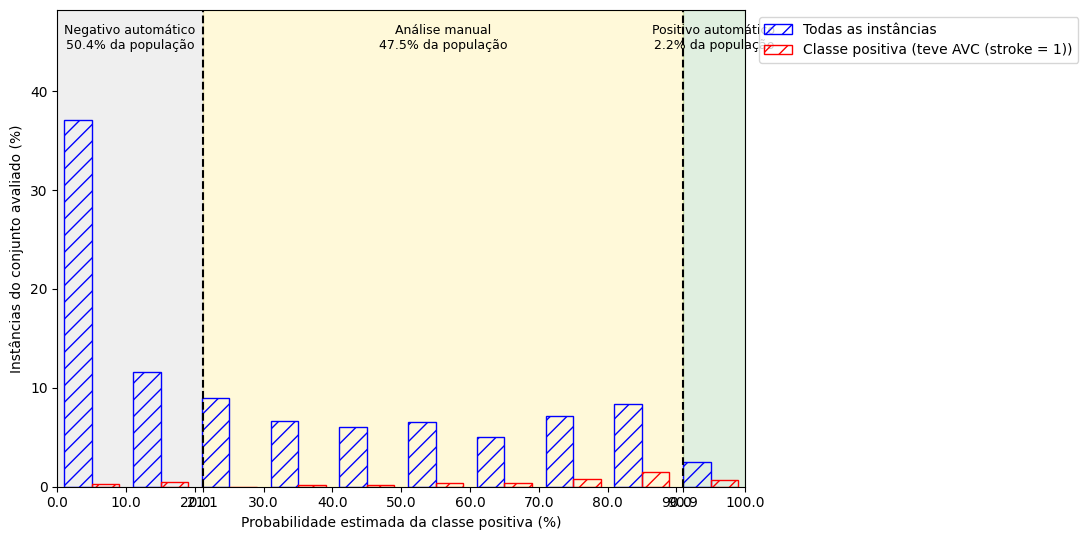

Relatório por faixa de decisão (conjunto de teste):


,Faixa,Instâncias,% da população (n / total_teste),Positivos reais,% positivos na faixa (pos / n),Negativos reais,% negativos na faixa (neg / n)
0,negativo_automatico,515,50.39,8,1.55,507,98.45
1,analise_manual,485,47.46,37,7.63,448,92.37
2,positivo_automatico,22,2.15,5,22.73,17,77.27



Positivos reais classificados automaticamente como negativos: 8/50 (16.00%; denominador = total de positivos reais)
Negativos reais classificados automaticamente como positivos: 17/972 (1.75%; denominador = total de negativos reais)


In [29]:
plot_histogram(y_test, prob_test, t1, t2, positive_class_definition="teve AVC (stroke = 1)", bin_width_pct=10)
_ = decision_band_report(y_test, prob_test, t1, t2)

**Resultado e justificativa da política de corte (teste):**

| Faixa | Pacientes | % da população | AVCs reais | Sem AVC |
|---|---|---|---|---|
| Negativo automático | 515 | 50,4% | 8 | 507 |
| Análise manual | 485 | 47,5% | 37 | 448 |
| Positivo automático | 22 | 2,2% | 5 (22,7% da faixa) | 17 |

- **AVCs classificados automaticamente como negativos: 8 de 50 (16%)**. A meta de perder cerca de 5% dos AVCs, calibrada na validação (3 de 50, 6%), **não se manteve no teste**: o erro grave ficou em mais que o dobro do esperado. A explicação principal é o tamanho da amostra: com 50 positivos, cada paciente vale 2 pontos percentuais, então a diferença entre 3 e 8 pacientes muda muito o percentual, e o percentil 5 da validação é definido por poucos casos. Ou seja, o corte t1 se ajustou a poucos pacientes da validação e não generalizou bem.
- **Negativos classificados automaticamente como positivos: 17 de 972 (1,75%)**, um erro baixo. A faixa positivo automático é pequena (22 pacientes) e tem precisão de 22,7% (5 de 22): é bem melhor que a taxa base (~4,9%), mas ainda assim 3 de cada 4 pacientes ali não tiveram AVC.
- **Metade da população (50,4%) é liberada automaticamente e quase metade (47,5%) vai para análise manual.** A faixa manual é grande porque o modelo raramente tem alta confiança: t2 é muito alto (0,91) e poucos pacientes o ultrapassam. A faixa manual concentra 37 dos 50 AVCs (74%), com taxa de AVC de 7,6%, cerca de 1,6 vezes a taxa da população.

**Política:** como um AVC não identificado pode custar a vida do paciente, é preferível encaminhar mais casos para revisão humana do que liberar automaticamente. Porém, os resultados mostram que, com este modelo e esta amostra, **o t1 escolhido ainda deixa passar uma fração relevante de AVCs (16%)**. Se o objetivo fosse manter esse erro perto de 5%, seria necessário um t1 mais baixo (mais casos na análise manual), ou escolher os cortes com validação cruzada para deixá-los mais estáveis. Não reajustamos t1 ou t2 depois de ver o teste, para que essa medida continue honesta.

**Limitações:** validação e teste têm apenas 50 AVCs cada; as probabilidades não são calibradas (`class_weight='balanced'`); e o desempenho do modelo é modesto (AUC-ROC ~0,80), então o sistema deve ser visto como apoio à triagem, não como decisão clínica.

## 10. Exportação do modelo final

In [30]:
joblib.dump(melhor_modelo, 'modelo_avc_pronto.pkl')
print(f"Modelo '{melhor_nome}' salvo em modelo_avc_pronto.pkl")

Modelo 'Regressão Logística' salvo em modelo_avc_pronto.pkl


# Wine Quality (Vinho Tinto)

**Responsável:** Marcos Vitor Oliveira de Luna

**Fonte:** https://archive.ics.uci.edu/dataset/186/wine+quality (UCI Machine Learning Repository, DOI 10.24432/C56S3T)

**Owner:** Paulo Cortez, António Cerdeira, Fernando Almeida, Telmo Matos e José Reis (Universidade do Minho). Artigo original: "Modeling wine preferences by data mining from physicochemical properties", Decision Support Systems, v. 47, n. 4, 2009.

**Licença:** Creative Commons Attribution 4.0 International (CC BY 4.0)

**Descrição:** base com 1.599 vinhos tintos da variedade portuguesa Vinho Verde. Cada linha é um vinho, descrito por 11 medidas físico-químicas feitas em laboratório (acidez, açúcar, álcool, pH, sulfatos etc.). Cada vinho também recebeu uma nota de qualidade de 0 a 10, dada por especialistas. O objetivo é prever se o vinho é de alta qualidade a partir dessas medidas.

**Variável-Alvo:** `alvo`, criada a partir da coluna `quality` (1 quando a nota é 7 ou mais, 0 quando é 6 ou menos)

**Classe Positiva:** 1 = "o vinho é de alta qualidade?"

## Como executar esta parte

1. Deixar o arquivo `winequality-red.csv` dentro da pasta `data/`, ao lado deste notebook (no Google Colab, criar a pasta `data` no painel de arquivos e enviar o CSV para ela).
2. Executar primeiro as células da Parte 1 (funções `assign_decision_band`, `plot_histogram` e `decision_band_report`), que ficam no início do notebook.
3. Executar as células desta seção em ordem, de cima para baixo (no Colab: Ambiente de execução > Executar tudo).
4. Bibliotecas usadas: pandas, numpy, scikit-learn (resultados gerados com a versão 1.6.1), matplotlib e shap. No Colab todas já vêm instaladas; fora dele: `pip install pandas numpy scikit-learn==1.6.1 matplotlib shap`.
5. Ao final, a última célula de código grava na pasta `data/` a base com a variável-alvo e as previsões de validação e teste.

In [31]:
import pandas as pd

df = pd.read_csv("./data/winequality-red.csv", sep=";")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


O que cada coluna significa:

| Coluna | Significado |
|---|---|
| fixed acidity | acidez fixa (ácidos naturais da uva) |
| volatile acidity | acidez volátil (em excesso dá gosto de vinagre) |
| citric acid | ácido cítrico (dá frescor) |
| residual sugar | açúcar que sobrou depois da fermentação |
| chlorides | cloretos (quantidade de sal) |
| free sulfur dioxide | dióxido de enxofre livre (conservante ativo) |
| total sulfur dioxide | dióxido de enxofre total (conservante total) |
| density | densidade |
| pH | pH (quanto mais baixo, mais ácido) |
| sulphates | sulfatos (aditivo que ajuda a conservar) |
| alcohol | teor alcoólico (%) |
| quality | nota de 0 a 10 dada por especialistas |

Antes de tudo, conferimos o tamanho da base e se existe algum valor faltando.

In [32]:
print(df.shape)
df.isnull().sum()

(1599, 12)


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


São 1.599 vinhos e 12 colunas, e nenhuma coluna tem valor faltando. Então não precisamos tratar dados ausentes.

## Criando a variável-alvo

A base não vem com uma resposta de sim ou não, e sim com uma nota de 0 a 10. Por isso criamos a coluna `alvo`: ela vale 1 quando a nota é 7 ou mais (vinho de alta qualidade) e 0 quando é 6 ou menos (vinho comum).

Depois de criar o alvo, apagamos a coluna `quality`. Se ela ficasse na base, o modelo teria a resposta na mão: bastaria olhar a nota para acertar, e o resultado não teria valor nenhum.

In [33]:
df["alvo"] = (df["quality"] >= 7).astype(int)
df = df.drop(columns="quality")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,alvo
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


## Verificação do balanceamento

Assim como nas outras bases, verificamos quantos vinhos existem de cada classe. Isso define quais métricas fazem sentido: numa base desbalanceada, a acurácia pode parecer boa mesmo quando o modelo não encontra quase nenhum caso da classe positiva.

In [34]:
print(df["alvo"].value_counts())
print(df["alvo"].value_counts(normalize=True) * 100)

alvo
0    1382
1     217
Name: count, dtype: int64
alvo
0    86.429018
1    13.570982
Name: proportion, dtype: float64


A base é **desbalanceada**: 86,4% dos vinhos são comuns e só 13,6% são de alta qualidade. Um modelo "preguiçoso", que dissesse que todo vinho é comum, teria 86,4% de acurácia sem encontrar nenhum vinho bom. Por isso a acurácia não pode ser a métrica principal aqui, e vamos olhar principalmente para precisão, recall, F1 e para as áreas das curvas ROC e Precision-Recall.

Também pensamos no **custo de cada erro** neste domínio:

- **Falso positivo** (vinho comum classificado como de alta qualidade): o vinho iria para a linha premium, o cliente pagaria mais por um vinho comum e a marca perderia credibilidade. É o erro mais grave.
- **Falso negativo** (vinho bom classificado como comum): o vinho seria vendido mais barato. É uma perda de dinheiro, mas não prejudica a reputação.

Por isso, a **métrica principal deste domínio é a precisão**, e na escolha dos cortes `t1`/`t2` vamos priorizar que quase nenhum vinho comum vá automaticamente para a linha premium.

## Separação em treino, validação e teste

Dividimos a base em três partes:

- **Treino (60%):** onde os modelos aprendem e onde é feita a validação cruzada para escolher os hiperparâmetros
- **Validação (20%):** usada para comparar os modelos e escolher os pontos de corte `t1` e `t2`
- **Teste (20%):** fica guardado e só é usado no final, uma vez, para medir o desempenho real do modelo escolhido

O `train_test_split` só divide em duas partes, então fizemos em duas etapas: primeiro 60% / 40%, depois dividimos os 40% ao meio. Usamos `stratify` para manter a mesma proporção de vinhos bons nas três partes, e `random_state=42` para que a divisão seja sempre a mesma quando o notebook for executado de novo.

In [35]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="alvo")
y = df["alvo"]

X_treino, X_temp, y_treino, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
X_val, X_teste, y_val, y_teste = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

for nome, yy in [("Treino", y_treino), ("Validação", y_val), ("Teste", y_teste)]:
    print(f"{nome}: {len(yy)} vinhos, {yy.sum()} bons ({yy.mean() * 100:.1f}%)")

Treino: 959 vinhos, 130 bons (13.6%)
Validação: 320 vinhos, 44 bons (13.8%)
Teste: 320 vinhos, 43 bons (13.4%)


A proporção de vinhos bons ficou praticamente igual nos três conjuntos (entre 13,4% e 13,8%), que é o efeito do `stratify`.

## Pré-processamento e primeiro modelo

Todas as variáveis são numéricas. Então não precisamos de One-Hot Encoding (não há variáveis categóricas) nem de TF-IDF (não há texto).

Para a Regressão Logística usamos o `StandardScaler`, porque as colunas estão em escalas muito diferentes: o dióxido de enxofre total passa de 200, enquanto a densidade fica perto de 1. Sem padronizar, o modelo daria peso demais para as colunas com números grandes.

O `StandardScaler` fica dentro de um **Pipeline**, junto com o modelo. Assim a média e o desvio padrão são calculados **só com os dados de treino**, e dentro da validação cruzada são recalculados em cada divisão, usando só a parte que está treinando. Isso evita vazamento de informação da validação e do teste para o treinamento.

Antes da comparação completa, treinamos uma Regressão Logística simples só para ver como o modelo devolve as probabilidades. A tabela abaixo mostra os 8 vinhos da validação com maior probabilidade de serem bons.

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

modelo = Pipeline([
    ("escala", StandardScaler()),
    ("classificador", LogisticRegression(max_iter=1000))
])

modelo.fit(X_treino, y_treino)

prob_val = modelo.predict_proba(X_val)[:, 1]

resultado = pd.DataFrame({
    "alcool": X_val["alcohol"].values,
    "acidez_volatil": X_val["volatile acidity"].values,
    "resposta_certa": y_val.values,
    "chance_de_ser_bom_%": (prob_val * 100).round(1)
})

resultado.sort_values("chance_de_ser_bom_%", ascending=False).head(8)

,alcool,acidez_volatil,resposta_certa,chance_de_ser_bom_%
83,12.6,0.32,1,86.7
313,12.5,0.25,1,77.3
241,12.6,0.41,1,74.8
280,12.0,0.49,0,73.0
301,13.1,0.54,1,72.5
215,13.5,0.29,0,72.0
14,12.0,0.40,0,64.6
135,12.4,0.33,1,64.5


O modelo não responde só "é bom" ou "não é": ele dá uma probabilidade para cada vinho. Os vinhos com maior probabilidade têm teor alcoólico alto (entre 12% e 13,5%), e dos 8 primeiros, 5 eram realmente bons. Quem decide a partir de qual probabilidade o vinho é considerado bom somos nós, e é isso que os cortes `t1` e `t2` da Parte 1 fazem.

## Comparação de três algoritmos com otimização de hiperparâmetros

Comparamos três algoritmos:

- **Regressão Logística:** dá um peso para cada característica e combina tudo numa probabilidade
- **Árvore de Decisão:** faz perguntas em sequência (por exemplo: "álcool maior que 11,5?")
- **Random Forest:** 300 árvores de decisão diferentes que votam juntas

Os hiperparâmetros foram escolhidos com `GridSearchCV`, que testa todas as combinações da grade, usando **validação cruzada estratificada de 5 partes** (`StratifiedKFold`) somente no conjunto de treino. Em cada rodada o modelo treina em 4 partes e é avaliado na parte que sobrou, e a nota final é a média das 5 rodadas.

Hiperparâmetros testados:

- `C` (Regressão Logística): o quanto o modelo pode se ajustar aos dados
- `max_depth` (árvores): quantas perguntas seguidas a árvore pode fazer
- `min_samples_leaf` (árvores): quantos vinhos, no mínimo, precisa ter em cada folha
- `class_weight` (os três): com `balanced`, errar um vinho bom pesa mais no treinamento, para compensar o desbalanceamento

A Árvore e o Random Forest não usam o `StandardScaler`, porque as árvores só comparam um valor com um limite, e a escala não muda essa comparação.

**Métrica-alvo da otimização: Average Precision (AP).** Escolhemos a AP por dois motivos. Primeiro, ela é calculada em cima da classe positiva, então não é enganada pelo desbalanceamento como a acurácia. Segundo, ela não depende de um limiar: mede se o modelo coloca os vinhos bons na frente dos comuns quando ordenamos os vinhos pela probabilidade. É disso que precisamos, porque a decisão final é tomada pelos cortes `t1` e `t2`.

In [37]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

validacao_cruzada = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

candidatos = {
    "Regressão Logística": (
        Pipeline([
            ("escala", StandardScaler()),
            ("classificador", LogisticRegression(max_iter=1000))
        ]),
        {
            "classificador__C": [0.01, 0.1, 1, 10, 100],
            "classificador__class_weight": [None, "balanced"]
        }
    ),
    "Árvore de Decisão": (
        Pipeline([
            ("classificador", DecisionTreeClassifier(random_state=42))
        ]),
        {
            "classificador__max_depth": [3, 5, 7, 10, None],
            "classificador__min_samples_leaf": [1, 5, 10, 20],
            "classificador__class_weight": [None, "balanced"]
        }
    ),
    "Random Forest": (
        Pipeline([
            ("classificador", RandomForestClassifier(n_estimators=300, random_state=42))
        ]),
        {
            "classificador__max_depth": [None, 5, 10],
            "classificador__min_samples_leaf": [1, 3, 5],
            "classificador__class_weight": [None, "balanced"]
        }
    )
}

buscas = {}
for nome, (pipeline, grade) in candidatos.items():
    busca = GridSearchCV(pipeline, grade, scoring="average_precision", cv=validacao_cruzada, n_jobs=-1)
    busca.fit(X_treino, y_treino)
    buscas[nome] = busca
    print(f"{nome}: AP média na validação cruzada = {busca.best_score_:.3f}")
    print(f"   Melhores hiperparâmetros: {busca.best_params_}\n")

Regressão Logística: AP média na validação cruzada = 0.491
   Melhores hiperparâmetros: {'classificador__C': 0.1, 'classificador__class_weight': 'balanced'}

Árvore de Decisão: AP média na validação cruzada = 0.418
   Melhores hiperparâmetros: {'classificador__class_weight': None, 'classificador__max_depth': 7, 'classificador__min_samples_leaf': 20}

Random Forest: AP média na validação cruzada = 0.614
   Melhores hiperparâmetros: {'classificador__class_weight': None, 'classificador__max_depth': None, 'classificador__min_samples_leaf': 1}



O **Random Forest** teve a maior AP na validação cruzada (0,614), bem acima da Regressão Logística (0,491) e da Árvore de Decisão (0,418). Um modelo que chutasse teria AP perto de 0,136, que é a proporção de vinhos bons. O Random Forest foi escolhido como o melhor modelo.

A floresta ganha da árvore sozinha porque os erros de uma árvore são compensados pelas outras na votação.

Observação: os resultados foram gerados no Google Colab, com scikit-learn 1.6.1. Em outras versões da biblioteca, o Random Forest pode dar números um pouco diferentes, por causa dos sorteios internos das árvores.

## Avaliação dos três modelos na validação

Agora avaliamos o melhor modelo de cada algoritmo no conjunto de validação, com todas as métricas pedidas.

Nas métricas que dependem de uma decisão de sim ou não (acurácia, precisão, recall, F1 e matriz de confusão), usamos o **limiar de 0,5**: se a probabilidade estimada for maior ou igual a 0,5, o vinho é classificado como de alta qualidade.

As colunas VP, FP, FN e VN são a matriz de confusão: verdadeiros positivos, falsos positivos, falsos negativos e verdadeiros negativos.

In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, auc, average_precision_score, confusion_matrix

LIMIAR = 0.5

def avaliar(modelo, X, y):
    prob = modelo.predict_proba(X)[:, 1]
    previsto = (prob >= LIMIAR).astype(int)
    precisoes, recalls, _ = precision_recall_curve(y, prob)
    vn, fp, fn, vp = confusion_matrix(y, previsto).ravel()
    return {
        "Acurácia": accuracy_score(y, previsto),
        "Precisão": precision_score(y, previsto, zero_division=0),
        "Recall": recall_score(y, previsto),
        "F1": f1_score(y, previsto),
        "AUC-ROC": roc_auc_score(y, prob),
        "AUC-PR (trapézio)": auc(recalls, precisoes),
        "AP": average_precision_score(y, prob),
        "VP": vp,
        "FP": fp,
        "FN": fn,
        "VN": vn
    }

tabela_val = pd.DataFrame({nome: avaliar(busca.best_estimator_, X_val, y_val) for nome, busca in buscas.items()}).T
tabela_val.round(3)

,Acurácia,Precisão,Recall,F1,AUC-ROC,AUC-PR (trapézio),AP,VP,FP,FN,VN
Regressão Logística,0.750,0.316,0.705,0.437,0.864,0.528,0.535,31.0,67.0,13.0,209.0
Árvore de Decisão,0.869,0.525,0.477,0.500,0.835,0.518,0.480,21.0,19.0,23.0,257.0
Random Forest,0.922,0.852,0.523,0.648,0.916,0.777,0.777,23.0,4.0,21.0,272.0


- A **Regressão Logística**, com `class_weight = balanced`, encontrou mais vinhos bons (recall 0,705), mas errou muito para o outro lado: 67 vinhos comuns foram classificados como bons, e a precisão ficou em 0,316. É o equilíbrio entre precisão e recall: quando um sobe, o outro costuma cair.
- A **Árvore de Decisão** ficou abaixo nas métricas que não dependem de limiar (AUC-ROC e AP).
- O **Random Forest** foi o melhor em quase todas as métricas e cometeu só 4 falsos positivos, com precisão de 0,852. Isso confirma, na validação, a escolha feita pela validação cruzada, e combina com a prioridade do domínio (precisão).

## Curvas ROC e Precision-Recall

**Como as curvas são construídas:** o modelo devolve uma probabilidade para cada vinho. Para montar a curva, o limiar é variado de 1 até 0. Em cada limiar, os vinhos com probabilidade maior ou igual a ele são classificados como positivos e calculamos duas taxas, que viram um ponto da curva. Ligando os pontos de todos os limiares, temos a curva.

- **Curva ROC:** eixo X é a taxa de falsos positivos (FP / total de negativos reais) e eixo Y é a taxa de verdadeiros positivos, ou recall (VP / total de positivos reais). Com o limiar em 1, nenhum vinho é positivo e a curva começa em (0, 0). Com o limiar em 0, todos são positivos e ela termina em (1, 1).
- **Curva Precision-Recall:** eixo X é o recall e eixo Y é a precisão (VP / total de vinhos previstos como positivos). Essa curva é mais útil em base desbalanceada, porque não usa os verdadeiros negativos, que são a grande maioria aqui.

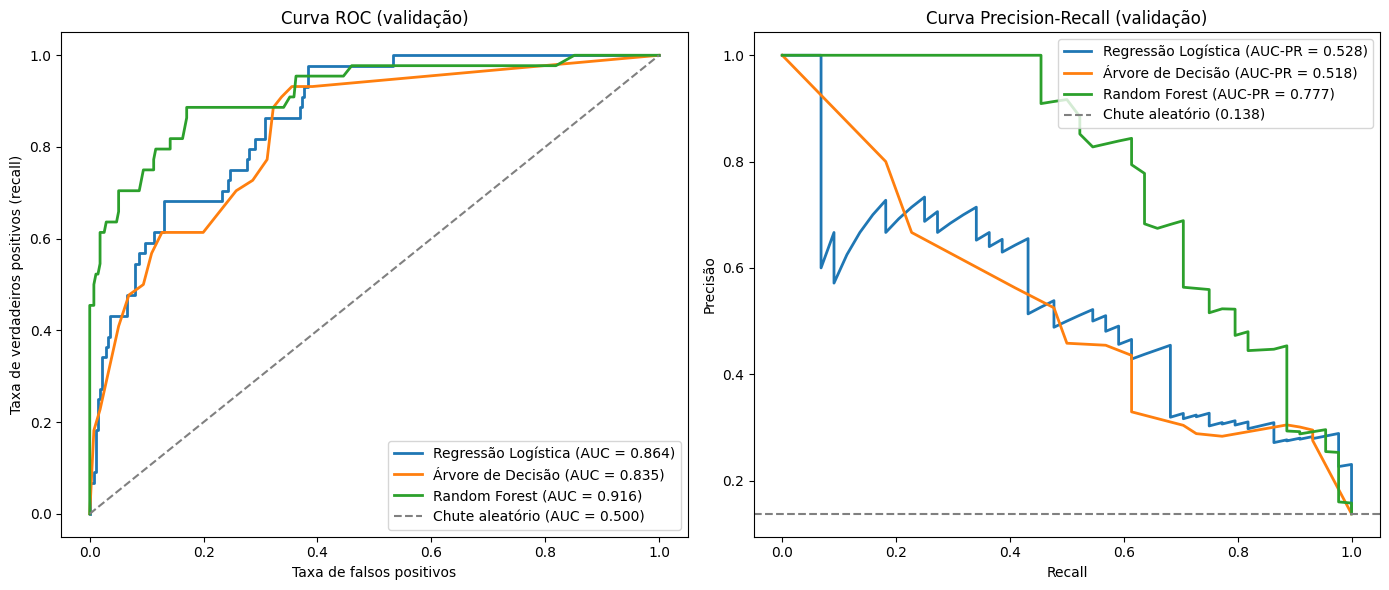

In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(14, 6))

for nome, busca in buscas.items():
    prob = busca.best_estimator_.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, prob)
    precisoes, recalls, _ = precision_recall_curve(y_val, prob)
    ax_roc.plot(fpr, tpr, linewidth=2, label=f"{nome} (AUC = {roc_auc_score(y_val, prob):.3f})")
    ax_pr.plot(recalls, precisoes, linewidth=2, label=f"{nome} (AUC-PR = {auc(recalls, precisoes):.3f})")

ax_roc.plot([0, 1], [0, 1], "--", color="gray", label="Chute aleatório (AUC = 0.500)")
ax_roc.set_title("Curva ROC (validação)")
ax_roc.set_xlabel("Taxa de falsos positivos")
ax_roc.set_ylabel("Taxa de verdadeiros positivos (recall)")
ax_roc.legend(loc="lower right")

proporcao_bons = y_val.mean()
ax_pr.axhline(proporcao_bons, linestyle="--", color="gray", label=f"Chute aleatório ({proporcao_bons:.3f})")
ax_pr.set_title("Curva Precision-Recall (validação)")
ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precisão")
ax_pr.legend(loc="upper right")

plt.tight_layout()
plt.show()

**Como as áreas são calculadas e interpretadas:**

- **AUC-ROC:** área sob a curva ROC, calculada com `roc_auc_score`. Vai de 0,5 (modelo que chuta, a linha tracejada) até 1,0 (modelo perfeito). Pode ser lida como a chance de o modelo dar uma probabilidade maior para um vinho bom do que para um vinho comum, escolhidos ao acaso.
- **AUC-PR (trapézio):** área sob a curva Precision-Recall, calculada com a função `auc`, que liga os pontos com retas e soma a área dos trapézios formados (integração trapezoidal). A referência de um modelo que chuta é a proporção de vinhos bons (0,138 na validação, a linha tracejada).
- **Average Precision (AP):** calculada com `average_precision_score`. Ela soma a precisão de cada ponto multiplicada pelo quanto o recall aumentou desde o ponto anterior, ou seja, soma degraus, sem ligar os pontos com retas. Por isso **a AP não é a mesma coisa que a AUC-PR por trapézio**, mesmo que os valores fiquem parecidos. A AP foi a métrica usada na escolha dos hiperparâmetros.

Nos dois gráficos, a curva do Random Forest (verde) fica acima das outras. Na curva Precision-Recall, ela se mantém com precisão de 100% até um recall perto de 0,45: os vinhos em que o modelo tinha mais certeza eram todos de alta qualidade.

## Interpretação do melhor modelo com SHAP

Para entender o que o Random Forest levou em conta, usamos o SHAP com o `TreeExplainer`, que é próprio para modelos de árvores.

- **Saída explicada:** a probabilidade da classe positiva (vinho de alta qualidade) estimada pelo Random Forest
- **Dados usados:** os 320 vinhos do conjunto de teste

Como ler o gráfico beeswarm: cada ponto é um vinho. A posição mostra quanto aquela característica aumentou (direita) ou diminuiu (esquerda) a probabilidade de o vinho ser de alta qualidade. A cor mostra o valor da característica: rosa é valor alto e azul é valor baixo. As características estão ordenadas da mais importante para a menos importante.

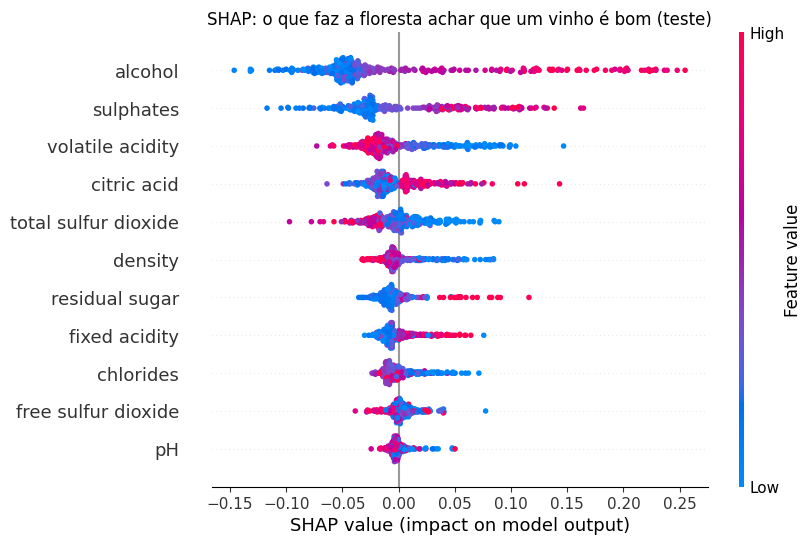

In [40]:
import shap

melhor_modelo = buscas["Random Forest"].best_estimator_
floresta = melhor_modelo.named_steps["classificador"]

explicador = shap.TreeExplainer(floresta)
valores_shap = explicador(X_teste)

shap.plots.beeswarm(valores_shap[:, :, 1], max_display=11, show=False)
plt.title("SHAP: o que faz a floresta achar que um vinho é bom (teste)")
plt.show()

- **Teor alcoólico (alcohol)** é a característica mais importante. Valores altos de álcool aumentam a probabilidade de o vinho ser de alta qualidade, chegando a somar cerca de 25 pontos percentuais. Valores baixos diminuem.
- **Sulfatos (sulphates)** vêm em segundo, com o mesmo sentido: valores altos aumentam a probabilidade e valores baixos diminuem.
- **Acidez volátil (volatile acidity)** tem o efeito contrário: valores altos, ligados ao gosto de vinagre, diminuem a probabilidade, e valores baixos aumentam.
- Depois aparecem o **ácido cítrico** (valores altos aumentam a probabilidade) e o **dióxido de enxofre total** e a **densidade** (valores altos diminuem).
- Cloretos, dióxido de enxofre livre e pH quase não influenciam: os pontos ficam concentrados perto de zero.

Esses padrões fazem sentido para vinho: mais álcool e menos acidez volátil costumam estar ligados a vinhos melhores. Ninguém ensinou isso ao modelo, ele descobriu olhando os exemplos, o que indica que aprendeu relações coerentes com o domínio.

## Aplicação do programa da Parte 1: escolha dos pontos de corte na validação

Usamos as funções da Parte 1 no Random Forest. Neste domínio, as três faixas significam:

- **Negativo automático** (probabilidade < `t1`): o vinho vai direto para a linha comum
- **Análise manual** (`t1` ≤ probabilidade < `t2`): o vinho é provado por um sommelier
- **Positivo automático** (probabilidade ≥ `t2`): o vinho vai direto para a linha premium

Os cortes são escolhidos **só com a validação**. Testamos 12 combinações e, para cada uma, anotamos o percentual de vinhos em cada faixa, quantos vinhos bons foram parar no negativo automático (de 44) e quantos vinhos comuns foram parar no positivo automático (de 276).

In [41]:
prob_val = melhor_modelo.predict_proba(X_val)[:, 1]
prob_teste = melhor_modelo.predict_proba(X_teste)[:, 1]

linhas = []
for t1 in [0.10, 0.15, 0.20, 0.25]:
    for t2 in [0.50, 0.60, 0.70]:
        faixa = assign_decision_band(prob_val, t1, t2)
        linhas.append({
            "t1": t1,
            "t2": t2,
            "% negativo automático": (faixa == "negativo_automatico").mean() * 100,
            "% análise manual": (faixa == "analise_manual").mean() * 100,
            "% positivo automático": (faixa == "positivo_automatico").mean() * 100,
            "bons perdidos (de 44)": ((y_val == 1) & (faixa == "negativo_automatico")).sum(),
            "comuns vendidos como premium (de 276)": ((y_val == 0) & (faixa == "positivo_automatico")).sum()
        })

pd.DataFrame(linhas).round(2)

,t1,t2,% negativo automático,% análise manual,% positivo automático,bons perdidos (de 44),comuns vendidos como premium (de 276)
0,0.10,0.5,60.31,31.25,8.44,5,4
1,0.10,0.6,60.31,33.12,6.56,5,1
2,0.10,0.7,60.31,37.19,2.50,5,0
3,0.15,0.5,67.81,23.75,8.44,5,4
4,0.15,0.6,67.81,25.62,6.56,5,1
5,0.15,0.7,67.81,29.69,2.50,5,0
6,0.20,0.5,75.00,16.56,8.44,8,4
7,0.20,0.6,75.00,18.44,6.56,8,1
8,0.20,0.7,75.00,22.50,2.50,8,0
9,0.25,0.5,78.75,12.81,8.44,9,4


Escolhemos **`t1 = 0,15` e `t2 = 0,60`**:

- **Por que `t1 = 0,15`:** subir o `t1` de 0,10 para 0,15 aumenta o negativo automático de 60,31% para 67,81% **sem perder nenhum vinho bom a mais** (continuam 5). Ou seja, o sommelier passa a ter menos trabalho sem custo nenhum. Subir para 0,20 aumentaria a automação para 75%, mas os vinhos bons descartados subiriam de 5 para 8. Por isso paramos em 0,15.
- **Por que `t2 = 0,60`:** com `t2 = 0,50`, 4 vinhos comuns iriam para a linha premium, que é o erro mais grave para a marca. Com `t2 = 0,70`, nenhum iria, mas só 2,5% dos vinhos seriam aprovados automaticamente e quase tudo cairia no colo do sommelier. Com `t2 = 0,60`, só 1 vinho comum em 276 foi para a linha premium, com 6,56% dos vinhos aprovados automaticamente.

O histograma da validação abaixo mostra os cortes escolhidos. Usamos intervalos de 5 pontos percentuais para que o corte de 15% caia exatamente na divisa entre dois intervalos.

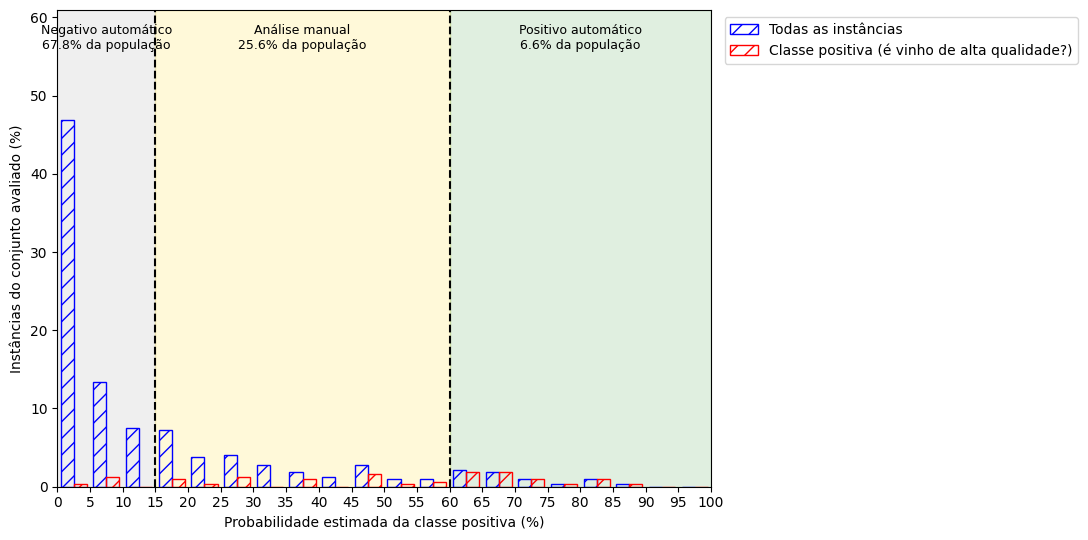

In [42]:
plot_histogram(y_val, prob_val, t1=0.15, t2=0.60, positive_class_definition="é vinho de alta qualidade?", bin_width_pct=5);

## Desempenho final do melhor modelo no teste

A partir daqui usamos o conjunto de teste, que ficou guardado até agora. O modelo e os cortes já estão definidos e **não são mais alterados**.

**Modelo final:** Random Forest com 300 árvores, `max_depth = None` (sem limite), `min_samples_leaf = 1`, `class_weight = None` e `random_state = 42`, treinado no conjunto de treino. As métricas com decisão usam o limiar de 0,5.

In [43]:
pd.DataFrame({"Random Forest (teste)": avaliar(melhor_modelo, X_teste, y_teste)}).T.round(3)

,Acurácia,Precisão,Recall,F1,AUC-ROC,AUC-PR (trapézio),AP,VP,FP,FN,VN
Random Forest (teste),0.916,0.864,0.442,0.585,0.945,0.749,0.753,19.0,3.0,24.0,274.0


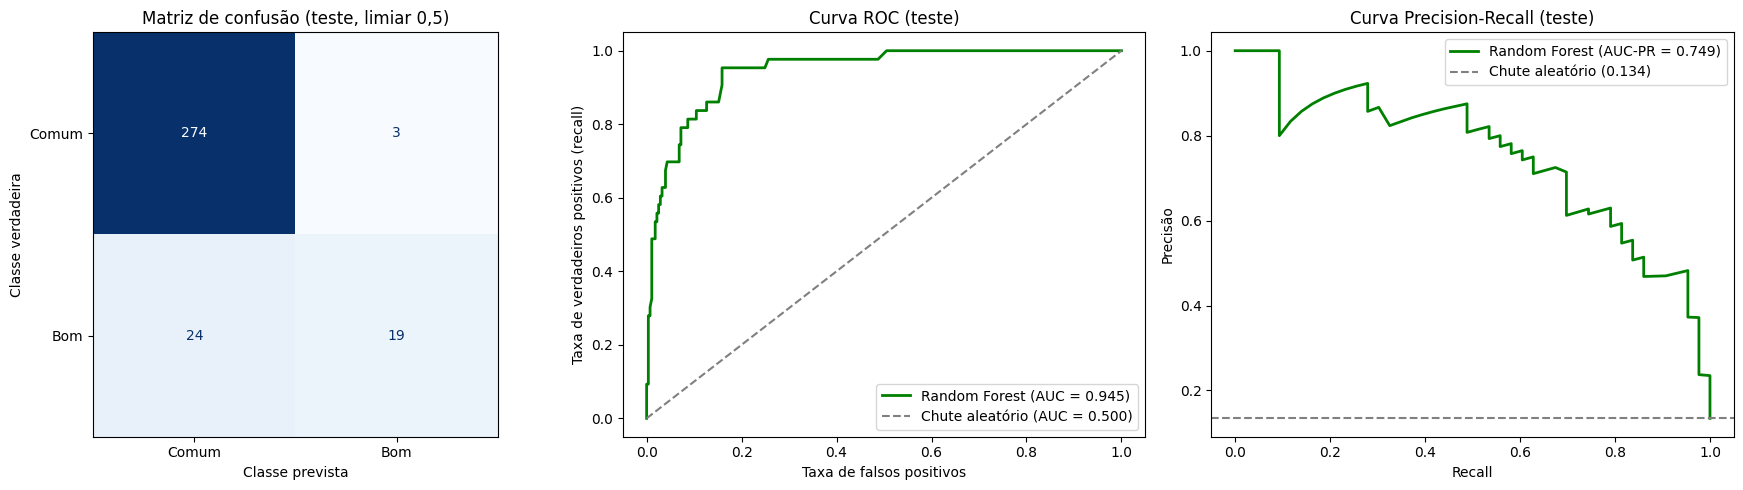

In [44]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, (ax_mc, ax_roc, ax_pr) = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(
    y_teste, (prob_teste >= LIMIAR).astype(int),
    display_labels=["Comum", "Bom"], cmap="Blues", colorbar=False, ax=ax_mc
)
ax_mc.set_title("Matriz de confusão (teste, limiar 0,5)")
ax_mc.set_xlabel("Classe prevista")
ax_mc.set_ylabel("Classe verdadeira")

fpr, tpr, _ = roc_curve(y_teste, prob_teste)
ax_roc.plot(fpr, tpr, linewidth=2, color="green", label=f"Random Forest (AUC = {roc_auc_score(y_teste, prob_teste):.3f})")
ax_roc.plot([0, 1], [0, 1], "--", color="gray", label="Chute aleatório (AUC = 0.500)")
ax_roc.set_title("Curva ROC (teste)")
ax_roc.set_xlabel("Taxa de falsos positivos")
ax_roc.set_ylabel("Taxa de verdadeiros positivos (recall)")
ax_roc.legend(loc="lower right")

precisoes, recalls, _ = precision_recall_curve(y_teste, prob_teste)
ax_pr.plot(recalls, precisoes, linewidth=2, color="green", label=f"Random Forest (AUC-PR = {auc(recalls, precisoes):.3f})")
ax_pr.axhline(y_teste.mean(), linestyle="--", color="gray", label=f"Chute aleatório ({y_teste.mean():.3f})")
ax_pr.set_title("Curva Precision-Recall (teste)")
ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precisão")
ax_pr.legend(loc="upper right")

plt.tight_layout()
plt.show()

- O resultado no teste ficou parecido com o da validação, e a AUC-ROC chegou a 0,945. O modelo funciona em vinhos que nunca viu, então não apenas decorou o treino.
- Na matriz de confusão, o modelo acertou 274 vinhos comuns e 19 vinhos bons, classificou 3 vinhos comuns como bons (falsos positivos) e 24 vinhos bons como comuns (falsos negativos).
- A precisão de 86,4% atende à prioridade do domínio. Mas o recall de 44,2% mostra que, com um limiar único de 0,5, mais da metade dos vinhos bons seria tratada como comum. As três faixas resolvem esse problema, como mostra a próxima etapa.

## Faixas de decisão no teste

Aplicamos no teste os cortes escolhidos na validação (`t1 = 0,15` e `t2 = 0,60`), sem nenhum ajuste.

In [45]:
decision_band_report(y_teste, prob_teste, t1=0.15, t2=0.60);

Relatório por faixa de decisão (conjunto de teste):


,Faixa,Instâncias,% da população (n / total_teste),Positivos reais,% positivos na faixa (pos / n),Negativos reais,% negativos na faixa (neg / n)
0,negativo_automatico,226,70.62,2,0.88,224,99.12
1,analise_manual,80,25.00,29,36.25,51,63.75
2,positivo_automatico,14,4.38,12,85.71,2,14.29



Positivos reais classificados automaticamente como negativos: 2/43 (4.65%; denominador = total de positivos reais)
Negativos reais classificados automaticamente como positivos: 2/277 (0.72%; denominador = total de negativos reais)


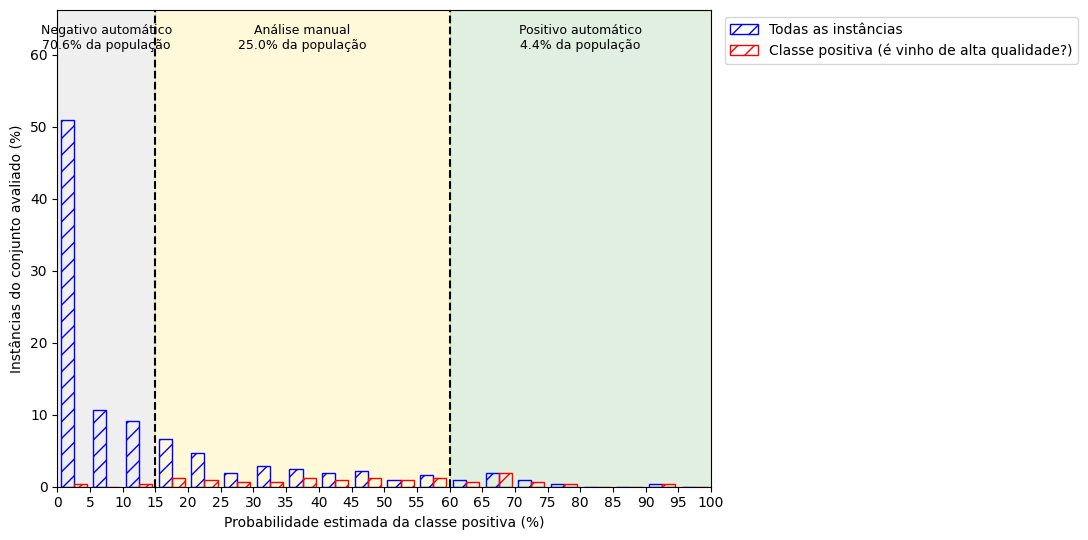

In [46]:
plot_histogram(y_teste, prob_teste, t1=0.15, t2=0.60, positive_class_definition="é vinho de alta qualidade?", bin_width_pct=5);

**Resultado no teste (320 vinhos: 43 bons e 277 comuns):**

- **Negativo automático:** 70,62% dos vinhos, com só 2 vinhos bons entre eles
- **Análise manual:** 25,00% dos vinhos, com 29 vinhos bons e 51 comuns
- **Positivo automático:** 4,38% dos vinhos, dos quais 12 eram bons e 2 eram comuns
- **Positivos classificados automaticamente como negativos:** 2 de 43 = **4,65%** (denominador: total de vinhos bons no teste)
- **Negativos classificados automaticamente como positivos:** 2 de 277 = **0,72%** (denominador: total de vinhos comuns no teste)

No histograma, a barra azul de 0% a 5% concentra cerca de metade dos vinhos e quase não tem vermelho: são vinhos que o modelo tem certeza de que são comuns, e ele acerta. Na faixa de positivo automático, as barras vermelhas têm quase a mesma altura das azuis, ou seja, quase todos os vinhos ali são bons de verdade.

**Justificativa da política:** 75% dos vinhos são decididos de forma automática, e o erro mais grave (vinho comum vendido como premium) ficou em 0,72% dos vinhos comuns. Com o limiar único de 0,5, 24 dos 43 vinhos bons seriam tratados como comuns. Com as três faixas, só 2 foram descartados automaticamente, e 29 vinhos bons foram para a análise manual, onde o sommelier pode recuperá-los. O custo é o sommelier avaliar 25% dos vinhos (80 de 320), volume que consideramos aceitável em troca de manter o erro contra a marca abaixo de 1%.

## Arquivos gerados

Salvamos na pasta `data/`:

- `vinho_tinto_qualidade.csv`: a base usada, com as 11 características e a variável-alvo
- `vinho_previsoes_validacao.csv` e `vinho_previsoes_teste.csv`: o rótulo real (`y_true`) e a probabilidade estimada da classe positiva (`y_prob`) do Random Forest, no formato usado pelas funções da Parte 1

In [47]:
df.to_csv("./data/vinho_tinto_qualidade.csv", index=False)

pd.DataFrame({"y_true": y_val.values, "y_prob": prob_val}).to_csv("./data/vinho_previsoes_validacao.csv", index=False)
pd.DataFrame({"y_true": y_teste.values, "y_prob": prob_teste}).to_csv("./data/vinho_previsoes_teste.csv", index=False)

## Conclusão do domínio

O Random Forest foi o melhor modelo para identificar vinhos tintos de alta qualidade a partir das medidas físico-químicas, com AUC-ROC de 0,945 e precisão de 86,4% no teste. O SHAP mostrou que o teor alcoólico, os sulfatos e a acidez volátil são os fatores que mais pesam na decisão, o que faz sentido para o domínio.

A política de três faixas foi o ponto principal: um limiar único obrigaria a escolher entre perder muitos vinhos bons ou aceitar mais vinhos comuns na linha premium. Com `t1 = 0,15` e `t2 = 0,60`, três quartos dos vinhos são decididos sem intervenção humana, com poucos erros automáticos, e os casos em que o modelo tem dúvida ficam com o especialista.